# Climate Dataset Analysis & Integration with Fire Data

## 📋 Processing Pipeline Structure

### **1. Load Climate Raster Files**
- Load country boundaries (Algeria & Tunisia shapefiles)
- Load raster files (precipitation, tmax, tmin)
- Extract dates from filenames

### **2. Initial EDA (BEFORE clipping)**
- Understand raster structure (CRS, resolution, bounds)
- Check temporal coverage (date ranges)
- Sample statistics per raster
- Quick visualizations (1-2 sample months)

### **3. Clip Rasters to Country Boundaries**
- Clip all climate rasters to Algeria & Tunisia
- Save clipped rasters (optional, for reuse)
- Verify clipping results

### **4. Comprehensive EDA on Clipped Climate Data**
- Descriptive statistics (mean, std, min, max per month)
- Univariate analysis (distributions, histograms)
- Bivariate analysis (prec vs tmax, tmax vs tmin)
- Temporal analysis (trends, seasonality)
- Spatial visualizations (heatmaps of climate variables)

### **5. Load Fire Points Data**
- Load fire CSV (longitude, latitude, class)
- Convert to GeoDataFrame
- Check spatial coverage

### **6. Extract Climate Values at Fire Point Locations** ⚡ KEY STEP
- For each fire point (lon, lat):
  - Extract precipitation value from raster
  - Extract tmax value from raster
  - Extract tmin value from raster
- Aggregate across time per season (winter, summer, spring, autumn)
- Create merged dataset: [longitude, latitude, class, prec_winter, prec_summer, ..., tmax_winter, tmax_summer, ..., tmin_winter, tmin_summer, ...]

### **7. Data Preprocessing**
- Drop duplicates
- Handle missing values:
  - Replace with median for numerical features
  - Replace with mode for categorical features
  - Replace with interpolation for date features
- Detect outliers with IQR and replace
- Normalize/standardize features

### **8. Merge and Save Final Preprocessed Dataset**
- Return CSV file containing fire data with climate features
- Final format: fires_with_climate.csv

# 0. Multithreading

In [1]:
import os
import multiprocessing

def configure_threading(max_threads=None):
    """Set thread env variables so numeric libs leverage multiple CPU cores."""
    if max_threads is None:
        max_threads = multiprocessing.cpu_count()
    thread_env_vars = [
        "OMP_NUM_THREADS",
        "OPENBLAS_NUM_THREADS",
        "MKL_NUM_THREADS",
        "VECLIB_MAXIMUM_THREADS",
        "NUMEXPR_NUM_THREADS",
    ]
    for var in thread_env_vars:
        os.environ[var] = str(max_threads)
    print(f"Threading configured to use up to {max_threads} CPU cores.")

configure_threading()

Threading configured to use up to 12 CPU cores.


# 1. Load Climate Raster Files

In [2]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import rasterio
from rasterio.mask import mask
import geopandas as gpd
from pathlib import Path
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')

# Base directory
BASE_DIR = Path(r'c:\Users\Azur\Downloads\TP\DM')

# Paths to data directories
PREC_DIR = BASE_DIR / 'dataset' / 'climate_dataset' / 'prec'
TMAX_DIR = BASE_DIR / 'dataset' / 'climate_dataset' / 'tmax'
TMIN_DIR = BASE_DIR / 'dataset' / 'climate_dataset' / 'tmin'
ALGERIA_SHP = BASE_DIR / 'dataset' / 'land_cover_dataset' / 'algeria' / 'dza_gc_adg.shp'
TUNISIA_SHP = BASE_DIR / 'dataset' / 'land_cover_dataset' / 'tunisia' / 'Tunisia_LC_2022_point_data.shp'
FIRES_CSV = BASE_DIR / 'results' / 'fires.csv'
OUTPUT_DIR = BASE_DIR / 'results'

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


# Country boundaries

Loading country boundaries...
✅ Algeria shapefile loaded - CRS: EPSG:4326
   Raw polygons: 386454
✅ Tunisia shapefile loaded - CRS: EPSG:4326
   Raw polygons: 4747

🔧 Dissolving polygons into single boundaries...
   Algeria after dissolve: 1 polygon(s)
   Tunisia after dissolve: 1 polygon(s)

✅ Combined boundaries: 2 polygons (MUCH BETTER!)
   Bounds: [-8.67386723 18.96002769 11.97954845 37.33608547]


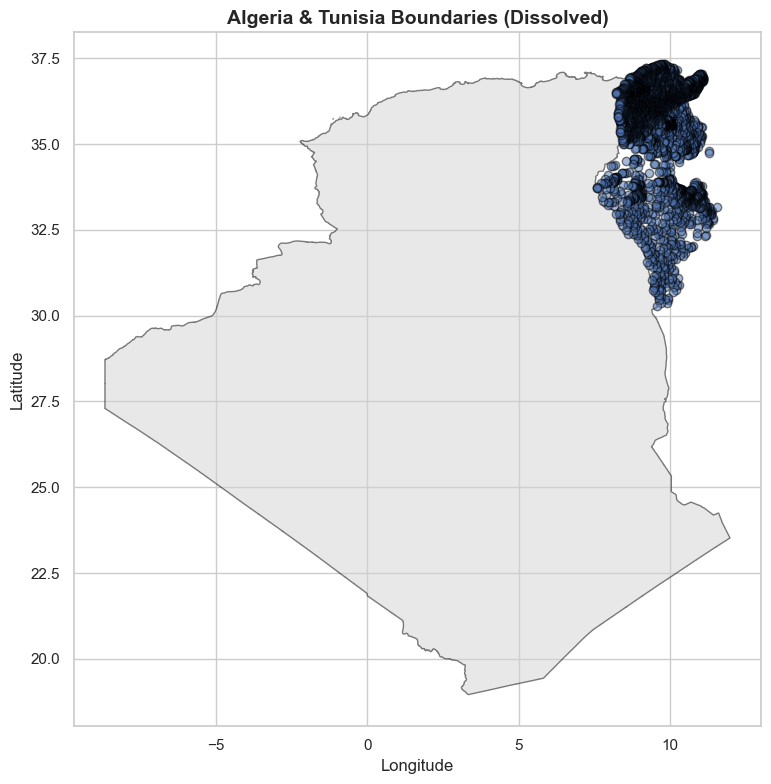

In [3]:
# Load country boundaries
def load_country_boundaries():
    """Load and combine Algeria and Tunisia boundaries."""
    print("Loading country boundaries...")
    
    # Check if files exist
    if not ALGERIA_SHP.exists():
        raise FileNotFoundError(f"Algeria shapefile not found: {ALGERIA_SHP}\nPlease update BASE_DIR in cell 4 to match your system")
    if not TUNISIA_SHP.exists():
        raise FileNotFoundError(f"Tunisia shapefile not found: {TUNISIA_SHP}\nPlease update BASE_DIR in cell 4 to match your system")
    
    algeria = gpd.read_file(ALGERIA_SHP)
    tunisia = gpd.read_file(TUNISIA_SHP)
    
    print(f"✅ Algeria shapefile loaded - CRS: {algeria.crs}")
    print(f"   Raw polygons: {len(algeria)}")
    print(f"✅ Tunisia shapefile loaded - CRS: {tunisia.crs}")
    print(f"   Raw polygons: {len(tunisia)}")
    
    # Ensure same CRS
    if tunisia.crs != algeria.crs:
        tunisia = tunisia.to_crs(algeria.crs)
        print(f"  Reprojected Tunisia to {algeria.crs}")
    
    # 🔥 FIX: Dissolve all polygons into ONE boundary per country
    print("\n🔧 Dissolving polygons into single boundaries...")
    algeria_dissolved = algeria.dissolve().reset_index(drop=True)
    tunisia_dissolved = tunisia.dissolve().reset_index(drop=True)
    
    print(f"   Algeria after dissolve: {len(algeria_dissolved)} polygon(s)")
    print(f"   Tunisia after dissolve: {len(tunisia_dissolved)} polygon(s)")
    
    # Combine boundaries
    boundaries = pd.concat([algeria_dissolved, tunisia_dissolved], ignore_index=True)
    
    print(f"\n✅ Combined boundaries: {len(boundaries)} polygons (MUCH BETTER!)")
    print(f"   Bounds: {boundaries.total_bounds}")
    
    return boundaries

boundaries = load_country_boundaries()

# Visualize boundaries
fig, ax = plt.subplots(figsize=(10, 8))
boundaries.plot(ax=ax, edgecolor='black', facecolor='lightgray', alpha=0.5)
ax.set_title('Algeria & Tunisia Boundaries (Dissolved)', fontsize=14, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()

# Raster files

In [4]:
# Load raster files and extract dates
def get_all_rasters(directory):
    """Get all raster files from a directory."""
    if not directory.exists():
        print(f"⚠️ Warning: Directory {directory} does not exist!")
        return []
    tifs = sorted(list(directory.glob('*.tif')) + list(directory.glob('*.TIF')))
    return tifs

def extract_date_from_filename(filename):
    """Extract date from filename pattern like 'wc2.1_cruts4.09_5m_TYPE_YYYY-MM.tif'"""
    try:
        name = filename.stem
        date_part = name.split('_')[-1]
        year, month = date_part.split('-')
        return pd.to_datetime(f"{year}-{month}-01")
    except:
        return None

# Load raster files
print("\nLoading raster files...")
prec_files = get_all_rasters(PREC_DIR)
tmax_files = get_all_rasters(TMAX_DIR)
tmin_files = get_all_rasters(TMIN_DIR)

print(f"✅ Precipitation files: {len(prec_files)}")
print(f"✅ Max Temperature files: {len(tmax_files)}")
print(f"✅ Min Temperature files: {len(tmin_files)}")

# Create date mappings
prec_map = {extract_date_from_filename(Path(f)): f for f in prec_files if extract_date_from_filename(Path(f)) is not None}
tmax_map = {extract_date_from_filename(Path(f)): f for f in tmax_files if extract_date_from_filename(Path(f)) is not None}
tmin_map = {extract_date_from_filename(Path(f)): f for f in tmin_files if extract_date_from_filename(Path(f)) is not None}

# Find common dates
common_dates = sorted(list(set(prec_map.keys()) & set(tmax_map.keys()) & set(tmin_map.keys())))
print(f"\n✅ Common dates across all variables: {len(common_dates)}")

if common_dates:
    print(f"   Date range: {min(common_dates).strftime('%Y-%m')} to {max(common_dates).strftime('%Y-%m')}")
    print(f"\n   Sample dates:")
    for date in common_dates[:5]:
        print(f"     - {date.strftime('%Y-%m')}")


Loading raster files...
✅ Precipitation files: 120
✅ Max Temperature files: 120
✅ Min Temperature files: 120

✅ Common dates across all variables: 60
   Date range: 2020-01 to 2024-12

   Sample dates:
     - 2020-01
     - 2020-02
     - 2020-03
     - 2020-04
     - 2020-05

✅ Common dates across all variables: 60
   Date range: 2020-01 to 2024-12

   Sample dates:
     - 2020-01
     - 2020-02
     - 2020-03
     - 2020-04
     - 2020-05


# 2. Initial EDA (BEFORE Clipping)

In [5]:
# Understand raster structure
def show_raster_structure(raster_file, name):
    """Display structure information for a raster file."""
    with rasterio.open(raster_file) as src:
        print(f"\n{'='*60}")
        print(f" {name}")
        print(f"{'='*60}")
        print(f"File: {Path(raster_file).name}")
        print(f"CRS: {src.crs}")
        print(f"Bounds: {src.bounds}")
        print(f"Width x Height: {src.width} x {src.height}")
        print(f"Resolution: {src.res}")
        print(f"Number of bands: {src.count}")
        print(f"Data type: {src.dtypes[0]}")
        print(f"NoData value: {src.nodata}")
        
        # Read and display sample statistics
        data = src.read(1)
        if src.nodata is not None:
            data = np.ma.masked_equal(data, src.nodata)
        
        print(f"\nSample Statistics:")
        print(f"  Min: {np.ma.min(data):.2f}")
        print(f"  Max: {np.ma.max(data):.2f}")
        print(f"  Mean: {np.ma.mean(data):.2f}")
        print(f"  Std: {np.ma.std(data):.2f}")
        print(f"  Valid pixels: {np.ma.count(data):,}")
        print(f"  NoData pixels: {np.ma.count_masked(data):,}")

# Show structure for first file of each type
if prec_files:
    show_raster_structure(prec_files[0], "PRECIPITATION (Sample)")
if tmax_files:
    show_raster_structure(tmax_files[0], "MAX TEMPERATURE (Sample)")
if tmin_files:
    show_raster_structure(tmin_files[0], "MIN TEMPERATURE (Sample)")


 PRECIPITATION (Sample)
File: wc2.1_cruts4.09_5m_prec_2020-01.tif
CRS: EPSG:4326
Bounds: BoundingBox(left=-180.0, bottom=-90.0, right=180.0, top=90.0)
Width x Height: 4320 x 2160
Resolution: (0.08333333333333333, 0.08333333333333333)
Number of bands: 1
Data type: float32
NoData value: nan

Sample Statistics:
  Min: nan
  Max: nan
  Mean: nan
  Std: --
  Valid pixels: 9,331,200
  NoData pixels: 0

 MAX TEMPERATURE (Sample)
File: wc2.1_cruts4.09_5m_tmax_2020-01.tif
CRS: EPSG:4326
Bounds: BoundingBox(left=-180.0, bottom=-90.0, right=180.0, top=90.0)
Width x Height: 4320 x 2160
Resolution: (0.08333333333333333, 0.08333333333333333)
Number of bands: 1
Data type: float32
NoData value: nan
  Mean: nan
  Std: --
  Valid pixels: 9,331,200
  NoData pixels: 0

 MAX TEMPERATURE (Sample)
File: wc2.1_cruts4.09_5m_tmax_2020-01.tif
CRS: EPSG:4326
Bounds: BoundingBox(left=-180.0, bottom=-90.0, right=180.0, top=90.0)
Width x Height: 4320 x 2160
Resolution: (0.08333333333333333, 0.08333333333333333)
Num


📊 Visualizing sample months (BEFORE clipping)...

Sample date: 2020-01



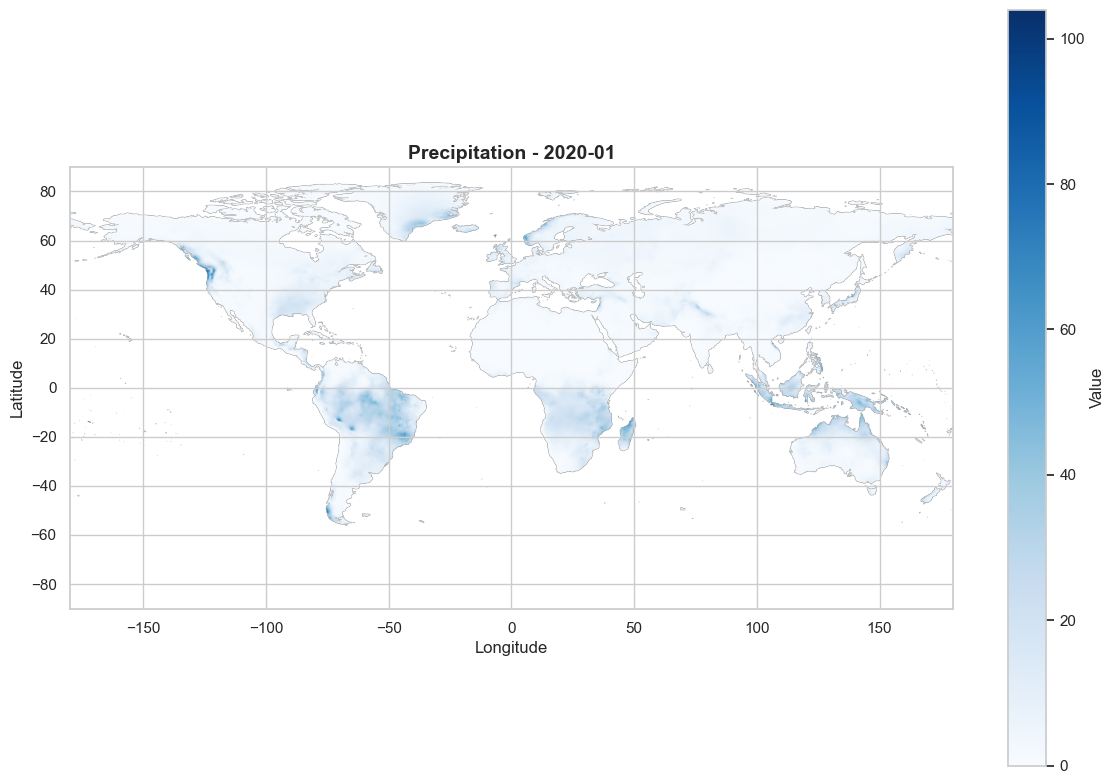

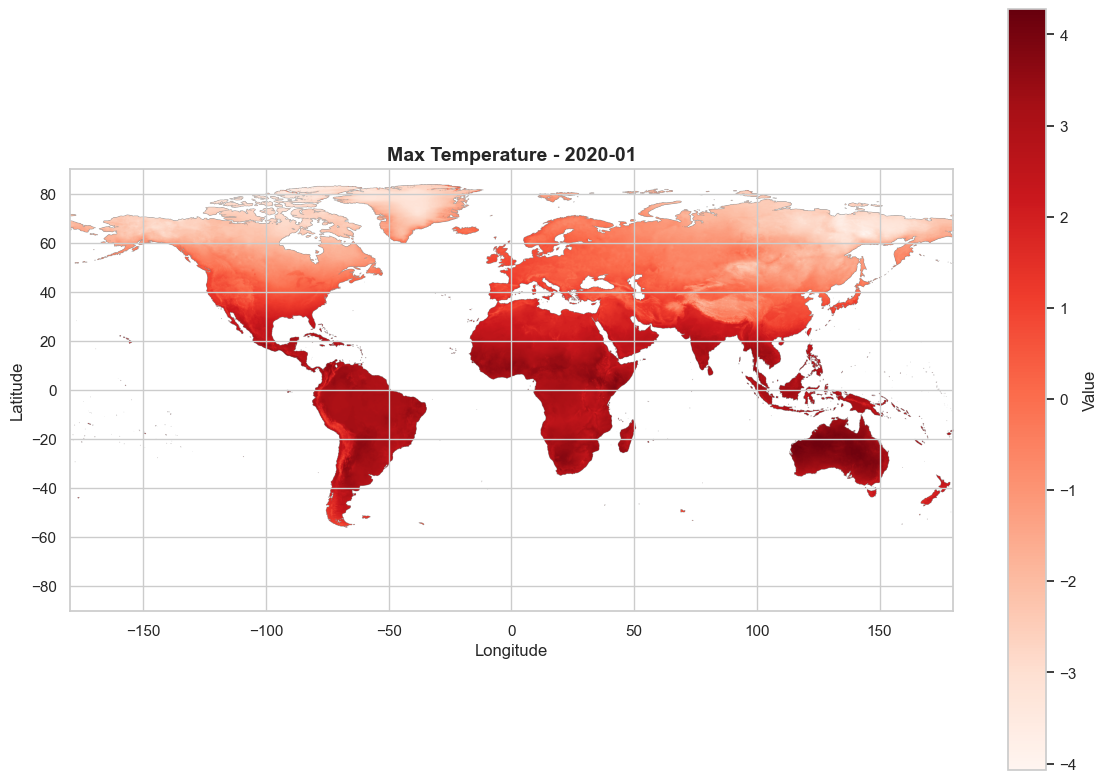

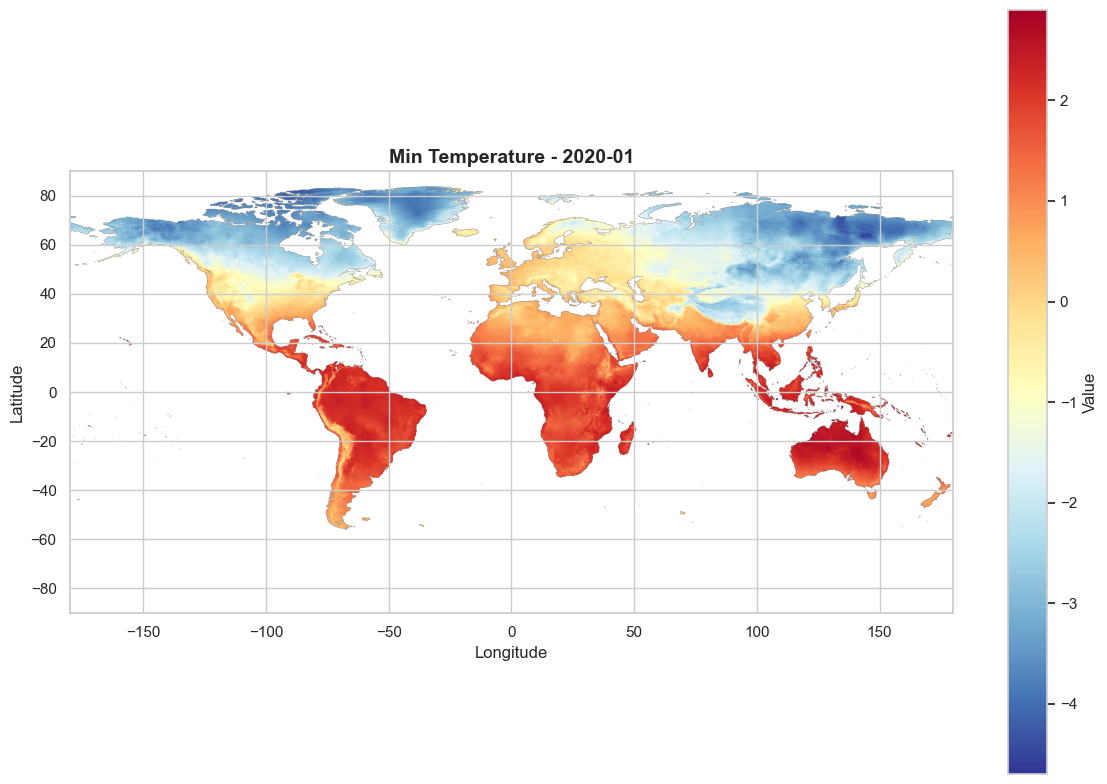

In [6]:
# Quick visualization of sample months
def plot_sample_raster(raster_file, title, cmap='viridis', multiplier=1.0):
    """Plot a single raster file."""
    with rasterio.open(raster_file) as src:
        data = src.read(1)
        if src.nodata is not None:
            data = np.ma.masked_equal(data, src.nodata)
        
        # Apply multiplier (e.g., 0.1 for temperature conversion)
        data = data * multiplier
        
        fig, ax = plt.subplots(figsize=(12, 8))
        im = ax.imshow(data, cmap=cmap, extent=[src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top])
        plt.colorbar(im, ax=ax, label='Value')
        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.set_xlabel('Longitude')
        ax.set_ylabel('Latitude')
        plt.tight_layout()
        plt.show()

# Plot first month from each variable
print("\n📊 Visualizing sample months (BEFORE clipping)...\n")

if common_dates:
    sample_date = common_dates[0]
    print(f"Sample date: {sample_date.strftime('%Y-%m')}\n")
    
    plot_sample_raster(prec_map[sample_date], f"Precipitation - {sample_date.strftime('%Y-%m')}", cmap='Blues', multiplier=0.1)
    plot_sample_raster(tmax_map[sample_date], f"Max Temperature - {sample_date.strftime('%Y-%m')}", cmap='Reds', multiplier=0.1)
    plot_sample_raster(tmin_map[sample_date], f"Min Temperature - {sample_date.strftime('%Y-%m')}", cmap='RdYlBu_r', multiplier=0.1)

# 3. Clip Rasters to Country Boundaries

In [7]:
# SUPER SIMPLE DIAGNOSTIC - Start here
print("="*60)
print("STEP-BY-STEP DIAGNOSTIC")
print("="*60)

print("\n🔍 STEP 1: Check if data loaded")
print(f"   Common dates found: {len(common_dates)}")
if len(common_dates) == 0:
    print("   ❌ ERROR: No common dates! Check if raster files were loaded correctly.")
else:
    print(f"   ✅ OK - Found {len(common_dates)} dates")
    print(f"   First date: {common_dates[0].strftime('%Y-%m')}")
    print(f"   Last date: {common_dates[-1].strftime('%Y-%m')}")

print("\n🔍 STEP 2: Check boundaries")
print(f"   Boundaries type: {type(boundaries)}")
print(f"   Boundaries shape: {boundaries.shape if hasattr(boundaries, 'shape') else 'N/A'}")
print(f"   Boundaries CRS: {boundaries.crs if hasattr(boundaries, 'crs') else 'N/A'}")

if len(common_dates) > 0:
    print("\n🔍 STEP 3: Test opening ONE raster file")
    test_date = common_dates[0]
    test_file = prec_map[test_date]
    print(f"   Test date: {test_date.strftime('%Y-%m')}")
    print(f"   Test file: {test_file}")
    print(f"   File exists: {Path(test_file).exists()}")
    
    if Path(test_file).exists():
        print("\n   Attempting to open raster...")
        try:
            import rasterio
            from rasterio.mask import mask
            
            src = rasterio.open(test_file)
            print(f"   ✅ Raster opened!")
            print(f"   ✅ CRS: {src.crs}")
            print(f"   ✅ Shape: {src.shape}")
            print(f"   ✅ Bounds: {src.bounds}")
            
            print("\n🔍 STEP 4: Test reprojecting boundaries")
            print(f"   Source CRS: {src.crs}")
            print(f"   Boundary CRS: {boundaries.crs}")
            
            if boundaries.crs != src.crs:
                print(f"   → Need to reproject boundaries...")
                boundaries_proj = boundaries.to_crs(src.crs)
                print(f"   ✅ Reprojection successful!")
            else:
                print(f"   ✅ CRS already matches, no reprojection needed")
                boundaries_proj = boundaries
            
            print("\n🔍 STEP 5: Attempt clipping")
            print(f"   Clipping raster to {len(boundaries_proj)} polygons...")
            
            out_image, out_transform = mask(src, boundaries_proj.geometry, crop=True)
            
            print(f"\n   🎉🎉🎉 CLIP SUCCESSFUL! 🎉🎉🎉")
            print(f"   Output shape: {out_image.shape}")
            print(f"   Output bands: {out_image.shape[0]}")
            print(f"   Output height: {out_image.shape[1]}")
            print(f"   Output width: {out_image.shape[2]}")
            
            src.close()
            
            print("\n" + "="*60)
            print("✅ ALL TESTS PASSED!")
            print("The clipping logic works fine.")
            print("Problem must be in the parallel execution.")
            print("="*60)
            
        except Exception as e:
            print(f"\n   ❌ ERROR OCCURRED: {e}")
            print(f"\n   Full traceback:")
            import traceback
            traceback.print_exc()
            
            print("\n" + "="*60)
            print("❌ CLIPPING FAILED")
            print("This is the root cause of your issue.")
            print("="*60)
    else:
        print(f"\n   ❌ ERROR: File does not exist!")
        print(f"   Check if the path is correct:")
        print(f"   {test_file}")
else:
    print("\n   ⚠️ Cannot test - no dates available")

print("\n" + "="*60)
print("RUN THIS CELL AND SHARE THE OUTPUT")
print("="*60)

STEP-BY-STEP DIAGNOSTIC

🔍 STEP 1: Check if data loaded
   Common dates found: 60
   ✅ OK - Found 60 dates
   First date: 2020-01
   Last date: 2024-12

🔍 STEP 2: Check boundaries
   Boundaries type: <class 'geopandas.geodataframe.GeoDataFrame'>
   Boundaries shape: (2, 9)
   Boundaries CRS: EPSG:4326

🔍 STEP 3: Test opening ONE raster file
   Test date: 2020-01
   Test file: c:\Users\Azur\Downloads\TP\DM\dataset\climate_dataset\prec\wc2.1_cruts4.09_5m_prec_2020-01.tif
   File exists: True

   Attempting to open raster...
   ✅ Raster opened!
   ✅ CRS: EPSG:4326
   ✅ Shape: (2160, 4320)
   ✅ Bounds: BoundingBox(left=-180.0, bottom=-90.0, right=180.0, top=90.0)

🔍 STEP 4: Test reprojecting boundaries
   Source CRS: EPSG:4326
   Boundary CRS: EPSG:4326
   ✅ CRS already matches, no reprojection needed

🔍 STEP 5: Attempt clipping
   Clipping raster to 2 polygons...

   🎉🎉🎉 CLIP SUCCESSFUL! 🎉🎉🎉
   Output shape: (1, 222, 249)
   Output bands: 1
   Output height: 222
   Output width: 249

✅ AL

In [8]:
# SIMPLE SEQUENTIAL VERSION (for testing - clips just 3 dates)
# Run this if the parallel version isn't working
import pickle
import time

print("\n🔧 Testing SEQUENTIAL clipping (3 dates only)...\n")

# Create output directory
CLIPPED_DIR = OUTPUT_DIR / 'clipped_rasters'
CLIPPED_DIR.mkdir(parents=True, exist_ok=True)

# Test with just first 3 dates
test_dates = common_dates[:3]
print(f"Testing with {len(test_dates)} dates: {[d.strftime('%Y-%m') for d in test_dates]}\n")

test_clipped_prec = {}
test_clipped_tmax = {}
test_clipped_tmin = {}

start_time = time.time()

for i, date in enumerate(test_dates, 1):
    print(f"\n[{i}/{len(test_dates)}] Processing {date.strftime('%Y-%m')}...")
    
    try:
        # Clip precipitation
        print(f"  → Clipping prec...")
        with rasterio.open(prec_map[date]) as src:
            boundaries_proj = boundaries.to_crs(src.crs) if boundaries.crs != src.crs else boundaries
            out_image, out_transform = mask(src, boundaries_proj.geometry, crop=True)
            out_meta = src.meta.copy()
            out_meta.update({
                "driver": "GTiff",
                "height": out_image.shape[1],
                "width": out_image.shape[2],
                "transform": out_transform
            })
            test_clipped_prec[date] = (out_image[0], out_transform, out_meta)
            print(f"  ✓ Prec done - shape: {out_image[0].shape}")
        
        # Clip tmax
        print(f"  → Clipping tmax...")
        with rasterio.open(tmax_map[date]) as src:
            boundaries_proj = boundaries.to_crs(src.crs) if boundaries.crs != src.crs else boundaries
            out_image, out_transform = mask(src, boundaries_proj.geometry, crop=True)
            out_meta = src.meta.copy()
            out_meta.update({
                "driver": "GTiff",
                "height": out_image.shape[1],
                "width": out_image.shape[2],
                "transform": out_transform
            })
            test_clipped_tmax[date] = (out_image[0], out_transform, out_meta)
            print(f"  ✓ Tmax done - shape: {out_image[0].shape}")
        
        # Clip tmin
        print(f"  → Clipping tmin...")
        with rasterio.open(tmin_map[date]) as src:
            boundaries_proj = boundaries.to_crs(src.crs) if boundaries.crs != src.crs else boundaries
            out_image, out_transform = mask(src, boundaries_proj.geometry, crop=True)
            out_meta = src.meta.copy()
            out_meta.update({
                "driver": "GTiff",
                "height": out_image.shape[1],
                "width": out_image.shape[2],
                "transform": out_transform
            })
            test_clipped_tmin[date] = (out_image[0], out_transform, out_meta)
            print(f"  ✓ Tmin done - shape: {out_image[0].shape}")
        
        elapsed = time.time() - start_time
        print(f"  ✓✓ Completed {date.strftime('%Y-%m')} in {elapsed:.1f}s total")
        
    except Exception as e:
        print(f"  ✗✗ ERROR: {e}")
        import traceback
        traceback.print_exc()

total_time = time.time() - start_time
print(f"\n{'='*60}")
print(f"✅ Sequential test complete!")
print(f"   Processed {len(test_dates)} dates in {total_time:.1f} seconds")
print(f"   Average: {total_time/len(test_dates):.2f} seconds per date")
print(f"   Estimated time for all {len(common_dates)} dates: {(total_time/len(test_dates)) * len(common_dates) / 60:.1f} minutes")
print(f"{'='*60}")

print(f"\nResults:")
print(f"  Clipped prec: {len(test_clipped_prec)} rasters")
print(f"  Clipped tmax: {len(test_clipped_tmax)} rasters")
print(f"  Clipped tmin: {len(test_clipped_tmin)} rasters")


🔧 Testing SEQUENTIAL clipping (3 dates only)...

Testing with 3 dates: ['2020-01', '2020-02', '2020-03']


[1/3] Processing 2020-01...
  → Clipping prec...
  ✓ Prec done - shape: (222, 249)
  → Clipping tmax...
  ✓ Prec done - shape: (222, 249)
  → Clipping tmax...
  ✓ Tmax done - shape: (222, 249)
  → Clipping tmin...
  ✓ Tmax done - shape: (222, 249)
  → Clipping tmin...
  ✓ Tmin done - shape: (222, 249)
  ✓✓ Completed 2020-01 in 0.9s total

[2/3] Processing 2020-02...
  → Clipping prec...
  ✓ Tmin done - shape: (222, 249)
  ✓✓ Completed 2020-01 in 0.9s total

[2/3] Processing 2020-02...
  → Clipping prec...
  ✓ Prec done - shape: (222, 249)
  → Clipping tmax...
  ✓ Prec done - shape: (222, 249)
  → Clipping tmax...
  ✓ Tmax done - shape: (222, 249)
  → Clipping tmin...
  ✓ Tmax done - shape: (222, 249)
  → Clipping tmin...
  ✓ Tmin done - shape: (222, 249)
  ✓✓ Completed 2020-02 in 1.8s total

[3/3] Processing 2020-03...
  → Clipping prec...
  ✓ Tmin done - shape: (222, 249)
  ✓✓ C

In [9]:
# Optimized parallel clipping with caching (Thread-based for Windows)
import pickle
from concurrent.futures import ThreadPoolExecutor, as_completed
import threading
import time

def clip_raster_to_boundaries(raster_path, boundaries):
    """
    Clip a raster to country boundaries.
    Returns clipped array and transform.
    """
    with rasterio.open(raster_path) as src:
        # Reproject boundaries if needed
        if boundaries.crs != src.crs:
            boundaries_proj = boundaries.to_crs(src.crs)
        else:
            boundaries_proj = boundaries
        
        # Perform the clip
        out_image, out_transform = mask(src, boundaries_proj.geometry, crop=True)
        out_meta = src.meta.copy()
        out_meta.update({
            "driver": "GTiff",
            "height": out_image.shape[1],
            "width": out_image.shape[2],
            "transform": out_transform
        })
        
        return out_image[0], out_transform, out_meta

def clip_single_date(date, prec_path, tmax_path, tmin_path, boundaries):
    """Clip all three variables for a single date."""
    # IMMEDIATE FEEDBACK - let's see if this function is even called
    print(f"  → Starting to clip {date.strftime('%Y-%m')}...")
    
    results = {}
    
    try:
        prec_data, prec_transform, prec_meta = clip_raster_to_boundaries(prec_path, boundaries)
        results['prec'] = (date, prec_data, prec_transform, prec_meta)
    except Exception as e:
        print(f"  ✗ Error in prec for {date.strftime('%Y-%m')}: {e}")
        results['prec'] = (date, None, None, None, str(e))
    
    try:
        tmax_data, tmax_transform, tmax_meta = clip_raster_to_boundaries(tmax_path, boundaries)
        results['tmax'] = (date, tmax_data, tmax_transform, tmax_meta)
    except Exception as e:
        print(f"  ✗ Error in tmax for {date.strftime('%Y-%m')}: {e}")
        results['tmax'] = (date, None, None, None, str(e))
    
    try:
        tmin_data, tmin_transform, tmin_meta = clip_raster_to_boundaries(tmin_path, boundaries)
        results['tmin'] = (date, tmin_data, tmin_transform, tmin_meta)
    except Exception as e:
        print(f"  ✗ Error in tmin for {date.strftime('%Y-%m')}: {e}")
        results['tmin'] = (date, None, None, None, str(e))
    
    print(f"  ✓ Completed {date.strftime('%Y-%m')}")
    return results

# Clip all rasters for common dates with parallel processing and caching
print("\n🔧 Clipping rasters to Algeria & Tunisia boundaries...\n")

# Create output directory for clipped rasters
CLIPPED_DIR = OUTPUT_DIR / 'clipped_rasters'
CLIPPED_DIR.mkdir(parents=True, exist_ok=True)

# Cache file path
cache_file = CLIPPED_DIR / 'clipped_cache.pkl'

# Check if cached data exists
if cache_file.exists():
    print("📦 Cache file found - Do you want to use it?")
    print(f"   Cache location: {cache_file}")
    print("   Loading from cache...")
    try:
        with open(cache_file, 'rb') as f:
            cached_data = pickle.load(f)
            clipped_prec = cached_data['prec']
            clipped_tmax = cached_data['tmax']
            clipped_tmin = cached_data['tmin']
        
        print(f"✅ Loaded from cache:")
        print(f"   Clipped precipitation: {len(clipped_prec)} rasters")
        print(f"   Clipped max temperature: {len(clipped_tmax)} rasters")
        print(f"   Clipped min temperature: {len(clipped_tmin)} rasters")
        print("\n💡 To reprocess, delete the cache file and rerun this cell")
    except Exception as e:
        print(f"⚠️ Error loading cache: {e}")
        print("Will reprocess all rasters...\n")
        try:
            cache_file.unlink()  # Delete corrupted cache
        except:
            pass
        clipped_prec = {}
        clipped_tmax = {}
        clipped_tmin = {}
else:
    print("No cache found - will process all rasters")
    clipped_prec = {}
    clipped_tmax = {}
    clipped_tmin = {}

# If no valid cache, process all rasters in parallel
if not clipped_prec:
    print(f"\n🚀 Clipping {len(common_dates)} dates using parallel processing...\n")
    
    # Determine number of workers (use most of CPU cores)
    max_workers = max(1, multiprocessing.cpu_count() - 1)
    print(f"💪 Using {max_workers} parallel threads")
    print(f"   Watch your Task Manager - CPU should spike!\n")
    
    # Thread-safe lock for dictionary updates
    lock = threading.Lock()
    total_dates = len(common_dates)
    start_time = time.time()
    
    # DIAGNOSTIC: Check first few paths
    print("🔍 DIAGNOSTIC - Checking first date paths:")
    first_date = common_dates[0]
    print(f"   Date: {first_date}")
    print(f"   Prec path exists: {Path(prec_map[first_date]).exists()}")
    print(f"   Tmax path exists: {Path(tmax_map[first_date]).exists()}")
    print(f"   Tmin path exists: {Path(tmin_map[first_date]).exists()}")
    print(f"   Boundaries type: {type(boundaries)}")
    print(f"   Boundaries len: {len(boundaries)}\n")
    
    # Process with ThreadPoolExecutor
    print(f"Starting parallel processing at {time.strftime('%H:%M:%S')}\n")
    
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        # Submit all tasks
        print("Submitting tasks to thread pool...")
        future_to_date = {}
        for date in common_dates:
            future = executor.submit(clip_single_date, date, prec_map[date], tmax_map[date], tmin_map[date], boundaries)
            future_to_date[future] = date
        
        print(f"✓ Submitted {len(future_to_date)} tasks\n")
        
        # Process results as they complete
        for i, future in enumerate(as_completed(future_to_date), 1):
            date = future_to_date[future]
            try:
                results = future.result()
                
                with lock:
                    # Process precipitation result
                    if len(results['prec']) == 4:
                        date_p, prec_data, prec_transform, prec_meta = results['prec']
                        clipped_prec[date_p] = (prec_data, prec_transform, prec_meta)
                    
                    # Process tmax result
                    if len(results['tmax']) == 4:
                        date_t, tmax_data, tmax_transform, tmax_meta = results['tmax']
                        clipped_tmax[date_t] = (tmax_data, tmax_transform, tmax_meta)
                    
                    # Process tmin result
                    if len(results['tmin']) == 4:
                        date_m, tmin_data, tmin_transform, tmin_meta = results['tmin']
                        clipped_tmin[date_m] = (tmin_data, tmin_transform, tmin_meta)
                
                # Print progress every date (for debugging)
                elapsed = time.time() - start_time
                percentage = (i / total_dates) * 100
                rate = i / elapsed if elapsed > 0 else 0
                eta = (total_dates - i) / rate if rate > 0 else 0
                print(f"Progress: {i}/{total_dates} ({percentage:.1f}%) | Rate: {rate:.1f} dates/sec | ETA: {eta:.0f}s")
                        
            except Exception as e:
                print(f"⚠️ Unexpected error processing {date.strftime('%Y-%m')}: {e}")
                import traceback
                traceback.print_exc()
    
    total_time = time.time() - start_time
    print(f"\n✅ Successfully clipped {len(common_dates)} dates in {total_time:.1f} seconds")
    print(f"   Average: {total_time/len(common_dates):.2f} seconds per date")
    print(f"   Clipped precipitation: {len(clipped_prec)} rasters")
    print(f"   Clipped max temperature: {len(clipped_tmax)} rasters")
    print(f"   Clipped min temperature: {len(clipped_tmin)} rasters")
    
    # Save to cache
    print("\n💾 Saving clipped data to cache for future use...")
    try:
        with open(cache_file, 'wb') as f:
            pickle.dump({
                'prec': clipped_prec,
                'tmax': clipped_tmax,
                'tmin': clipped_tmin
            }, f, protocol=pickle.HIGHEST_PROTOCOL)
        print(f"✅ Cache saved to: {cache_file}")
        print(f"   Next time you run this notebook, it will load from cache in seconds!")
    except Exception as e:
        print(f"⚠️ Could not save cache: {e}")
        print("   (This won't affect the current processing)")



🔧 Clipping rasters to Algeria & Tunisia boundaries...

📦 Cache file found - Do you want to use it?
   Cache location: c:\Users\Azur\Downloads\TP\DM\results\clipped_rasters\clipped_cache.pkl
   Loading from cache...
⚠️ Error loading cache: No module named 'numpy._core.numeric'
Will reprocess all rasters...


🚀 Clipping 60 dates using parallel processing...

💪 Using 11 parallel threads
   Watch your Task Manager - CPU should spike!

🔍 DIAGNOSTIC - Checking first date paths:
   Date: 2020-01-01 00:00:00
   Prec path exists: True
   Tmax path exists: True
   Tmin path exists: True
   Boundaries type: <class 'geopandas.geodataframe.GeoDataFrame'>
   Boundaries len: 2

Starting parallel processing at 09:41:35

Submitting tasks to thread pool...
  → Starting to clip 2020-01...
  → Starting to clip 2020-02...
  → Starting to clip 2020-03...
  → Starting to clip 2020-04...
  → Starting to clip 2020-05...
  → Starting to clip 2020-06...
  → Starting to clip 2020-07...
  → Starting to clip 2020-


📊 Verifying clipping results...



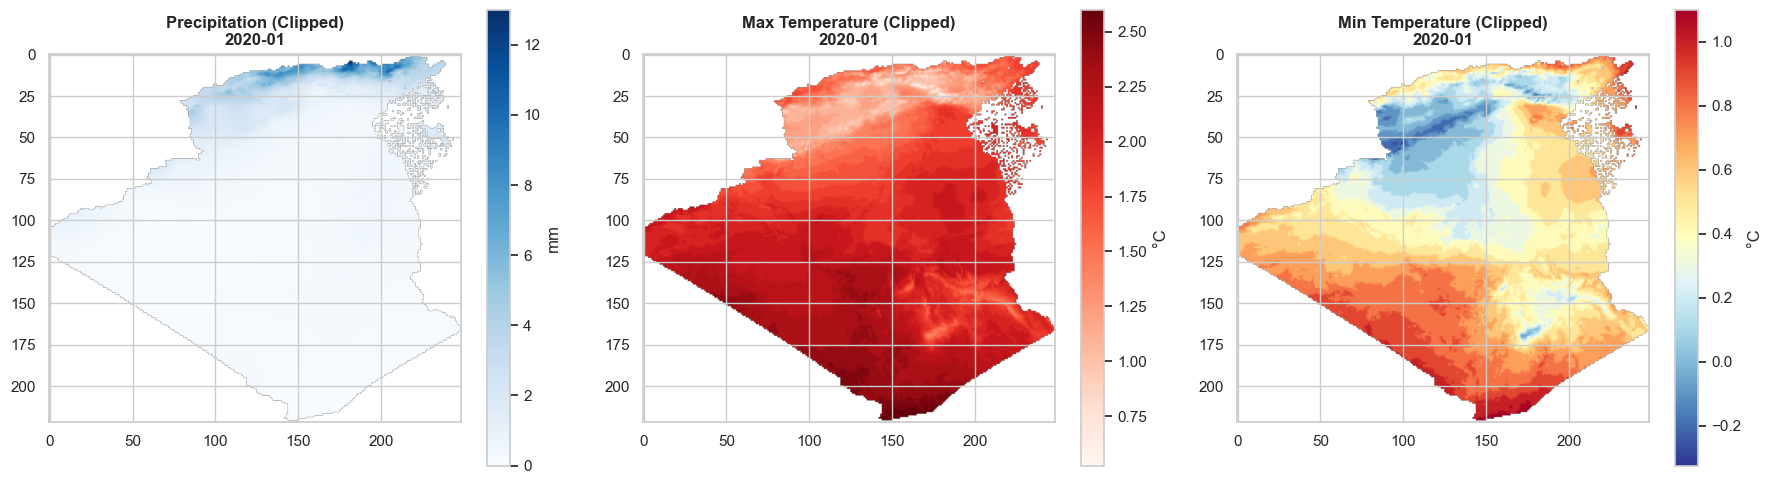

✅ Clipping verified for 2020-01


In [10]:
# Verify clipping results - visualize one clipped raster
print("\n📊 Verifying clipping results...\n")

if common_dates:
    sample_date = common_dates[0]
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Precipitation
    prec_data = clipped_prec[sample_date][0] * 0.1
    prec_data_masked = np.ma.masked_equal(prec_data, clipped_prec[sample_date][2]['nodata'])
    im1 = axes[0].imshow(prec_data_masked, cmap='Blues')
    plt.colorbar(im1, ax=axes[0], label='mm')
    axes[0].set_title(f'Precipitation (Clipped)\n{sample_date.strftime("%Y-%m")}', fontweight='bold')
    
    # Max Temperature
    tmax_data = clipped_tmax[sample_date][0] * 0.1
    tmax_data_masked = np.ma.masked_equal(tmax_data, clipped_tmax[sample_date][2]['nodata'])
    im2 = axes[1].imshow(tmax_data_masked, cmap='Reds')
    plt.colorbar(im2, ax=axes[1], label='°C')
    axes[1].set_title(f'Max Temperature (Clipped)\n{sample_date.strftime("%Y-%m")}', fontweight='bold')
    
    # Min Temperature
    tmin_data = clipped_tmin[sample_date][0] * 0.1
    tmin_data_masked = np.ma.masked_equal(tmin_data, clipped_tmin[sample_date][2]['nodata'])
    im3 = axes[2].imshow(tmin_data_masked, cmap='RdYlBu_r')
    plt.colorbar(im3, ax=axes[2], label='°C')
    axes[2].set_title(f'Min Temperature (Clipped)\n{sample_date.strftime("%Y-%m")}', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print(f"✅ Clipping verified for {sample_date.strftime('%Y-%m')}")

# 4. Comprehensive EDA on Clipped Climate Data

In [11]:
# Calculate descriptive statistics for clipped data
def calculate_clipped_statistics(clipped_data_dict, multiplier=1.0, var_name='Variable'):
    """Calculate statistics for all clipped rasters."""
    stats_list = []
    
    for date, (data, transform, meta) in clipped_data_dict.items():
        # FIX: Handle NaN as nodata value properly
        # np.ma.masked_equal doesn't work with NaN because NaN != NaN
        # Use masked_invalid to handle NaN, inf, etc.
        if meta.get('nodata') is not None and not np.isnan(meta['nodata']):
            # If nodata is a real number (not NaN), mask it
            data_masked = np.ma.masked_equal(data, meta['nodata'])
        else:
            # If nodata is NaN or not set, mask invalid values (NaN, inf)
            data_masked = np.ma.masked_invalid(data)
        
        # Apply multiplier
        data_masked = data_masked * multiplier
        
        stats_list.append({
            'date': date,
            'min': float(np.ma.min(data_masked)),
            'max': float(np.ma.max(data_masked)),
            'mean': float(np.ma.mean(data_masked)),
            'median': float(np.ma.median(data_masked)),
            'std': float(np.ma.std(data_masked)),
            'valid_pixels': int(np.ma.count(data_masked))
        })
    
    df_stats = pd.DataFrame(stats_list).sort_values('date')
    return df_stats

print("\n📊 Calculating statistics for clipped data...\n")

prec_stats = calculate_clipped_statistics(clipped_prec, multiplier=0.1, var_name='Precipitation')
tmax_stats = calculate_clipped_statistics(clipped_tmax, multiplier=0.1, var_name='Max Temperature')
tmin_stats = calculate_clipped_statistics(clipped_tmin, multiplier=0.1, var_name='Min Temperature')

print("✅ Statistics calculated\n")

print("Precipitation Statistics:")
display(prec_stats.head(10))

print("\nMax Temperature Statistics:")
display(tmax_stats.head(10))

print("\nMin Temperature Statistics:")
display(tmin_stats.head(10))


📊 Calculating statistics for clipped data...

✅ Statistics calculated

Precipitation Statistics:
✅ Statistics calculated

Precipitation Statistics:


,date,min,max,mean,median,std,valid_pixels
3,2020-01-01,0.0,12.995000,0.591046,0.1500,1.248136,31916
8,2020-02-01,0.0,7.295000,0.213389,0.1000,0.511966,31916
0,2020-03-01,0.0,22.164999,0.938236,0.2000,2.201290,31916
10,2020-04-01,0.0,16.570000,1.048287,0.1600,2.150766,31916
1,2020-05-01,0.0,5.822500,0.383836,0.1350,0.639100,31916
4,2020-06-01,0.0,2.187500,0.197595,0.0900,0.334442,31916
2,2020-07-01,0.0,3.180000,0.198561,0.1000,0.335691,31916
5,2020-08-01,0.0,3.960000,0.290158,0.1600,0.443754,31916
6,2020-09-01,0.0,9.082500,0.763371,0.2400,1.367469,31916
9,2020-10-01,0.0,8.115001,0.370668,0.1475,0.670593,31916



Max Temperature Statistics:


,date,min,max,mean,median,std,valid_pixels
3,2020-01-01,0.525,2.60,1.926787,2.000,0.359962,31916
8,2020-02-01,0.775,2.90,2.281001,2.350,0.351237,31916
0,2020-03-01,1.000,3.50,2.613496,2.700,0.449197,31916
10,2020-04-01,1.475,3.90,3.060226,3.200,0.480143,31916
1,2020-05-01,1.950,4.25,3.591912,3.700,0.433307,31916
4,2020-06-01,2.400,4.60,3.961040,4.100,0.431974,31916
2,2020-07-01,2.800,4.90,4.176701,4.275,0.384687,31916
5,2020-08-01,2.750,4.75,4.078814,4.200,0.365610,31916
6,2020-09-01,2.175,4.50,3.716505,3.800,0.439272,31916
9,2020-10-01,1.475,3.90,3.125498,3.200,0.466465,31916



Min Temperature Statistics:


,date,min,max,mean,median,std,valid_pixels
3,2020-01-01,-0.325,1.100,0.492777,0.500,0.266442,31916
8,2020-02-01,-0.050,1.300,0.806151,0.800,0.228129,31916
0,2020-03-01,-0.025,1.900,1.142478,1.125,0.304058,31916
10,2020-04-01,0.375,2.300,1.598167,1.675,0.327499,31916
1,2020-05-01,0.675,2.700,2.122577,2.200,0.346548,31916
4,2020-06-01,1.025,3.000,2.471893,2.600,0.377493,31916
2,2020-07-01,1.325,3.225,2.681021,2.700,0.327633,31916
5,2020-08-01,1.350,3.200,2.630926,2.700,0.317100,31916
6,2020-09-01,0.975,3.000,2.315230,2.350,0.375831,31916
9,2020-10-01,0.475,2.450,1.719128,1.750,0.367468,31916


DIAGNOSTIC - Checking Clipped Data Quality

1. Number of clipped rasters:
   Precipitation: 60
   Max Temperature: 60
   Min Temperature: 60

2. Sample clipped raster (date: 2020-03):
   Data shape: (222, 249)
   Data type: float32
   NoData value: nan
   Data min: nan
   Data max: nan
   Unique values count: 3390
   NoData pixels: 0
   Valid pixels: 55,278
   Percentage valid: 100.00%

3. Quick visualization of clipped data:


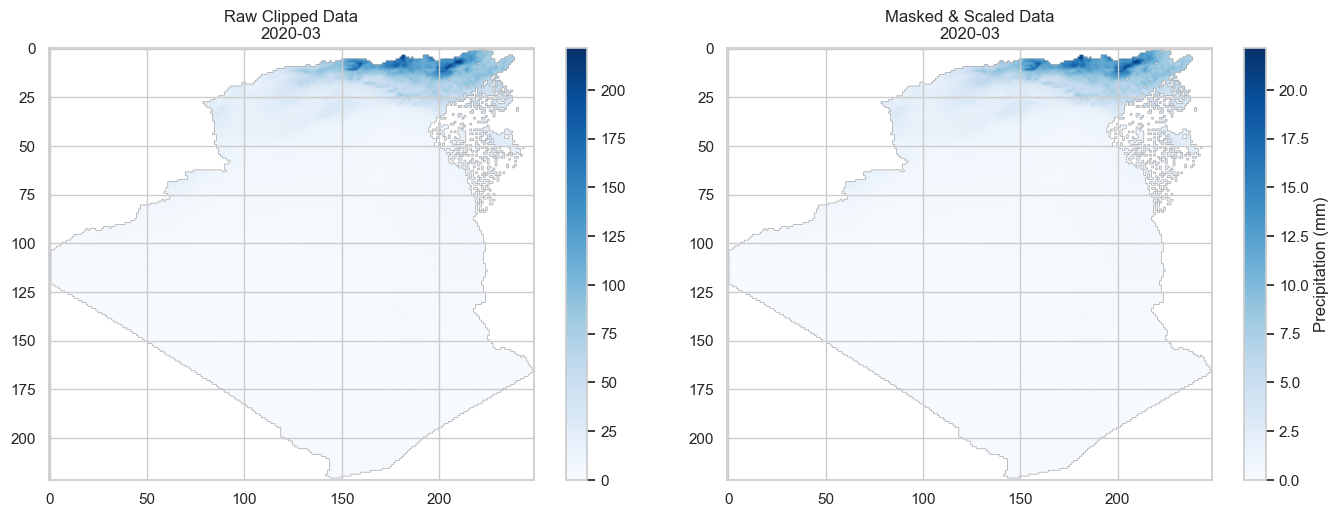


4. Check if boundaries overlap with data:
   Boundaries bounds: [-8.67386723 18.96002769 11.97954845 37.33608547]
   Raster transform: | 0.08, 0.00,-8.75|
| 0.00,-0.08, 37.42|
| 0.00, 0.00, 1.00|



In [12]:
# 🔍 DIAGNOSTIC: Check clipped data quality
print("="*60)
print("DIAGNOSTIC - Checking Clipped Data Quality")
print("="*60)

print(f"\n1. Number of clipped rasters:")
print(f"   Precipitation: {len(clipped_prec)}")
print(f"   Max Temperature: {len(clipped_tmax)}")
print(f"   Min Temperature: {len(clipped_tmin)}")

if len(clipped_prec) > 0:
    # Check first clipped raster
    first_date = list(clipped_prec.keys())[0]
    prec_data, prec_transform, prec_meta = clipped_prec[first_date]
    
    print(f"\n2. Sample clipped raster (date: {first_date.strftime('%Y-%m')}):")
    print(f"   Data shape: {prec_data.shape}")
    print(f"   Data type: {prec_data.dtype}")
    print(f"   NoData value: {prec_meta.get('nodata', 'Not set')}")
    print(f"   Data min: {prec_data.min()}")
    print(f"   Data max: {prec_data.max()}")
    print(f"   Unique values count: {len(np.unique(prec_data))}")
    
    # Check for nodata
    if prec_meta.get('nodata') is not None:
        nodata_count = np.sum(prec_data == prec_meta['nodata'])
        valid_count = np.sum(prec_data != prec_meta['nodata'])
        print(f"   NoData pixels: {nodata_count:,}")
        print(f"   Valid pixels: {valid_count:,}")
        print(f"   Percentage valid: {100 * valid_count / prec_data.size:.2f}%")
        
        # Check if ALL values are nodata
        if valid_count == 0:
            print(f"\n   ⚠️⚠️⚠️ WARNING: ALL PIXELS ARE NODATA!")
            print(f"   This means the clipping didn't capture any valid data!")
            print(f"   Possible causes:")
            print(f"     - Boundaries don't overlap with raster data")
            print(f"     - Boundaries are outside the raster extent")
            print(f"     - CRS mismatch issue")
    
    # Visualize to confirm
    print(f"\n3. Quick visualization of clipped data:")
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Raw data
    im1 = axes[0].imshow(prec_data, cmap='Blues')
    plt.colorbar(im1, ax=axes[0])
    axes[0].set_title(f'Raw Clipped Data\n{first_date.strftime("%Y-%m")}')
    
    # Masked data - handle NaN nodata properly
    if prec_meta.get('nodata') is not None and not np.isnan(prec_meta['nodata']):
        prec_masked = np.ma.masked_equal(prec_data, prec_meta['nodata'])
    else:
        # NoData is NaN or not set - use masked_invalid
        prec_masked = np.ma.masked_invalid(prec_data)
    
    im2 = axes[1].imshow(prec_masked * 0.1, cmap='Blues')
    plt.colorbar(im2, ax=axes[1], label='Precipitation (mm)')
    axes[1].set_title(f'Masked & Scaled Data\n{first_date.strftime("%Y-%m")}')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n4. Check if boundaries overlap with data:")
    print(f"   Boundaries bounds: {boundaries.total_bounds}")
    print(f"   Raster transform: {prec_transform}")
    
else:
    print("\n❌ ERROR: No clipped data found!")
    print("   You need to run the clipping cell first.")

print("\n" + "="*60)

In [13]:
# 🔍 DIAGNOSTIC: Test statistics calculation on ONE raster
print("="*60)
print("DIAGNOSTIC - Test Statistics on Single Raster")
print("="*60)

if len(clipped_prec) > 0:
    first_date = list(clipped_prec.keys())[0]
    data, transform, meta = clipped_prec[first_date]
    
    print(f"\nTesting date: {first_date.strftime('%Y-%m')}")
    print(f"Raw data shape: {data.shape}")
    print(f"NoData value in meta: {meta.get('nodata')}")
    
    # Step-by-step calculation
    print("\nStep 1: Check raw data")
    print(f"  Min: {data.min()}")
    print(f"  Max: {data.max()}")
    print(f"  Mean: {data.mean()}")
    
    print("\nStep 2: Apply masking")
    if meta.get('nodata') is not None:
        print(f"  NoData value in meta: {meta['nodata']}")
        if np.isnan(meta['nodata']):
            print("  NoData is NaN - using masked_invalid")
            data_masked = np.ma.masked_invalid(data)
        else:
            print(f"  NoData is {meta['nodata']} - using masked_equal")
            data_masked = np.ma.masked_equal(data, meta['nodata'])
    else:
        print("  No nodata value - masking invalid")
        data_masked = np.ma.masked_invalid(data)
    
    print(f"  Masked array count: {np.ma.count(data_masked)}")
    print(f"  Masked (NoData) count: {np.ma.count_masked(data_masked)}")
    
    print("\nStep 3: Apply multiplier (0.1)")
    data_masked = data_masked * 0.1
    
    print("\nStep 4: Calculate statistics")
    try:
        min_val = float(np.ma.min(data_masked))
        max_val = float(np.ma.max(data_masked))
        mean_val = float(np.ma.mean(data_masked))
        median_val = float(np.ma.median(data_masked))
        std_val = float(np.ma.std(data_masked))
        
        print(f"  Min: {min_val}")
        print(f"  Max: {max_val}")
        print(f"  Mean: {mean_val}")
        print(f"  Median: {median_val}")
        print(f"  Std: {std_val}")
        
        if np.isnan(mean_val):
            print("\n  ⚠️⚠️⚠️ WARNING: Mean is NaN!")
            print("  This happens when ALL pixels are masked (NoData)")
            print("  The clipped raster has NO valid data!")
        else:
            print("\n  ✅ Statistics calculated successfully!")
            
    except Exception as e:
        print(f"\n  ❌ ERROR calculating statistics: {e}")
        import traceback
        traceback.print_exc()
else:
    print("\n❌ No clipped data to test!")

print("\n" + "="*60)

DIAGNOSTIC - Test Statistics on Single Raster

Testing date: 2020-03
Raw data shape: (222, 249)
NoData value in meta: nan

Step 1: Check raw data
  Min: nan
  Max: nan
  Mean: nan

Step 2: Apply masking
  NoData value in meta: nan
  NoData is NaN - using masked_invalid
  Masked array count: 31916
  Masked (NoData) count: 23362

Step 3: Apply multiplier (0.1)

Step 4: Calculate statistics
  Min: 0.0
  Max: 22.16499900817871
  Mean: 0.9382358794374295
  Median: 0.20000000298023224
  Std: 2.201290250336857

  ✅ Statistics calculated successfully!




📊 Univariate Analysis - Distributions



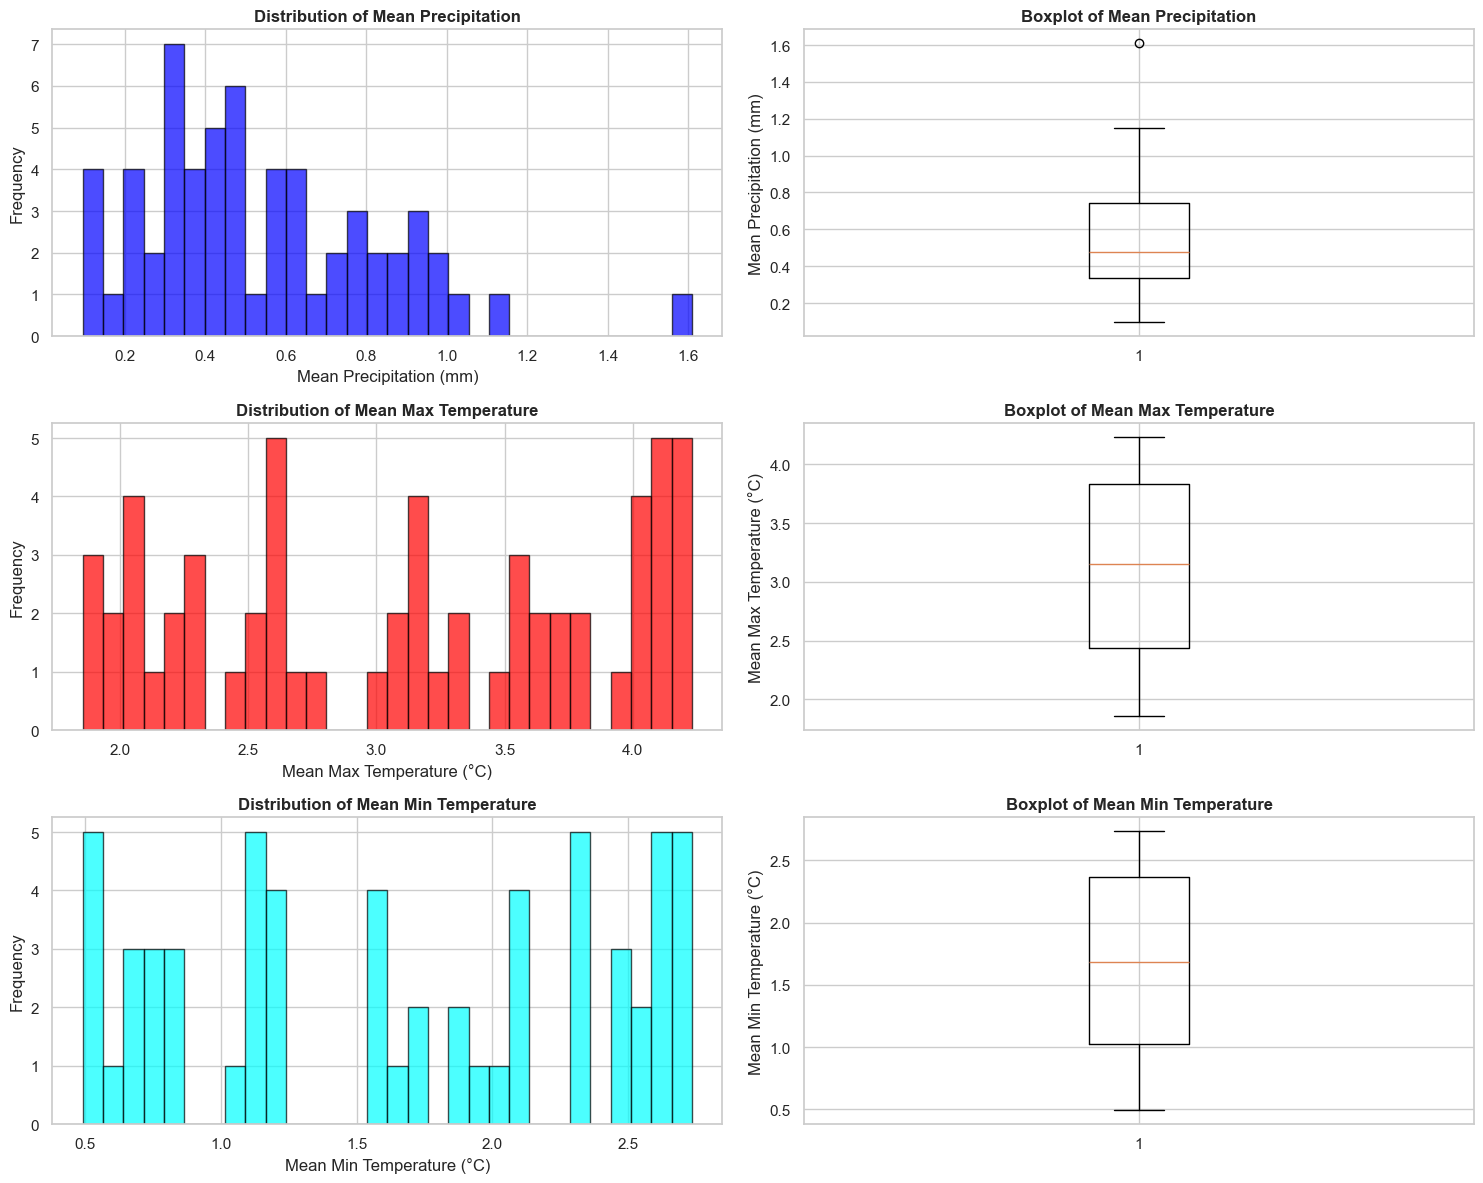

In [14]:
# Univariate analysis - distributions
print("\n📊 Univariate Analysis - Distributions\n")

fig, axes = plt.subplots(3, 2, figsize=(15, 12))

# Precipitation
axes[0, 0].hist(prec_stats['mean'], bins=30, edgecolor='black', color='blue', alpha=0.7)
axes[0, 0].set_title('Distribution of Mean Precipitation', fontweight='bold')
axes[0, 0].set_xlabel('Mean Precipitation (mm)')
axes[0, 0].set_ylabel('Frequency')

axes[0, 1].boxplot(prec_stats['mean'])
axes[0, 1].set_title('Boxplot of Mean Precipitation', fontweight='bold')
axes[0, 1].set_ylabel('Mean Precipitation (mm)')

# Max Temperature
axes[1, 0].hist(tmax_stats['mean'], bins=30, edgecolor='black', color='red', alpha=0.7)
axes[1, 0].set_title('Distribution of Mean Max Temperature', fontweight='bold')
axes[1, 0].set_xlabel('Mean Max Temperature (°C)')
axes[1, 0].set_ylabel('Frequency')

axes[1, 1].boxplot(tmax_stats['mean'])
axes[1, 1].set_title('Boxplot of Mean Max Temperature', fontweight='bold')
axes[1, 1].set_ylabel('Mean Max Temperature (°C)')

# Min Temperature
axes[2, 0].hist(tmin_stats['mean'], bins=30, edgecolor='black', color='cyan', alpha=0.7)
axes[2, 0].set_title('Distribution of Mean Min Temperature', fontweight='bold')
axes[2, 0].set_xlabel('Mean Min Temperature (°C)')
axes[2, 0].set_ylabel('Frequency')

axes[2, 1].boxplot(tmin_stats['mean'])
axes[2, 1].set_title('Boxplot of Mean Min Temperature', fontweight='bold')
axes[2, 1].set_ylabel('Mean Min Temperature (°C)')

plt.tight_layout()
plt.show()


📊 Bivariate Analysis - Correlations



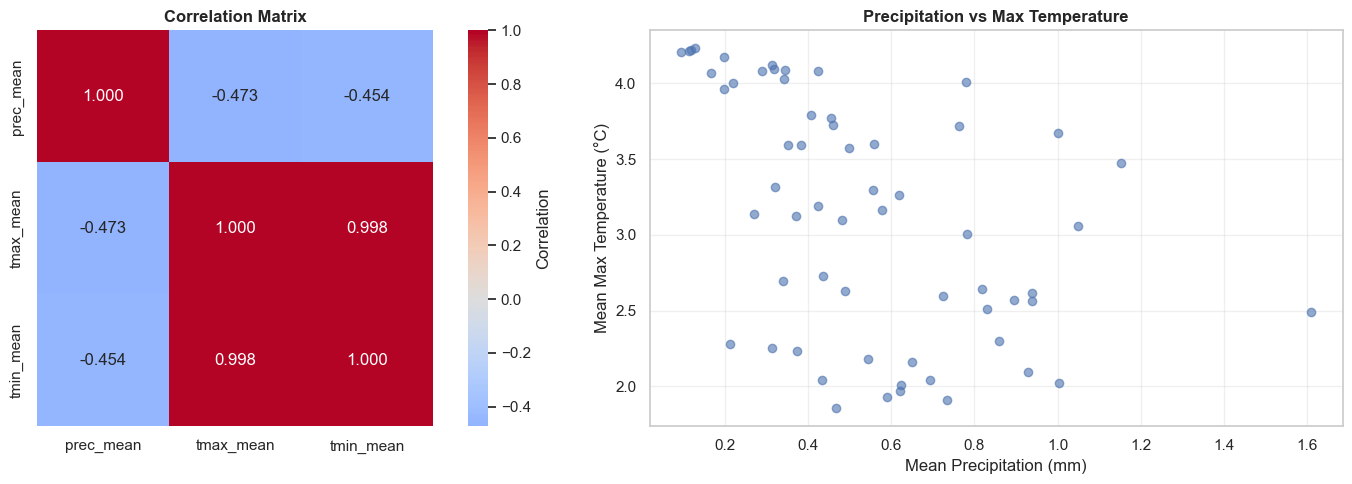


Correlation Matrix:


,prec_mean,tmax_mean,tmin_mean
prec_mean,1.000000,-0.472983,-0.453709
tmax_mean,-0.472983,1.000000,0.997873
tmin_mean,-0.453709,0.997873,1.000000


In [15]:
# Bivariate analysis - correlations
print("\n📊 Bivariate Analysis - Correlations\n")

# Combine statistics for correlation analysis
combined_stats = pd.DataFrame({
    'date': prec_stats['date'],
    'prec_mean': prec_stats['mean'],
    'tmax_mean': tmax_stats['mean'],
    'tmin_mean': tmin_stats['mean']
})

# Correlation matrix
corr_matrix = combined_stats[['prec_mean', 'tmax_mean', 'tmin_mean']].corr()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, ax=axes[0], 
            fmt='.3f', square=True, cbar_kws={'label': 'Correlation'})
axes[0].set_title('Correlation Matrix', fontweight='bold')

# Scatter plot: Precipitation vs Max Temperature
axes[1].scatter(combined_stats['prec_mean'], combined_stats['tmax_mean'], alpha=0.6)
axes[1].set_xlabel('Mean Precipitation (mm)')
axes[1].set_ylabel('Mean Max Temperature (°C)')
axes[1].set_title('Precipitation vs Max Temperature', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nCorrelation Matrix:")
display(corr_matrix)


📊 Temporal Analysis - Trends & Seasonality



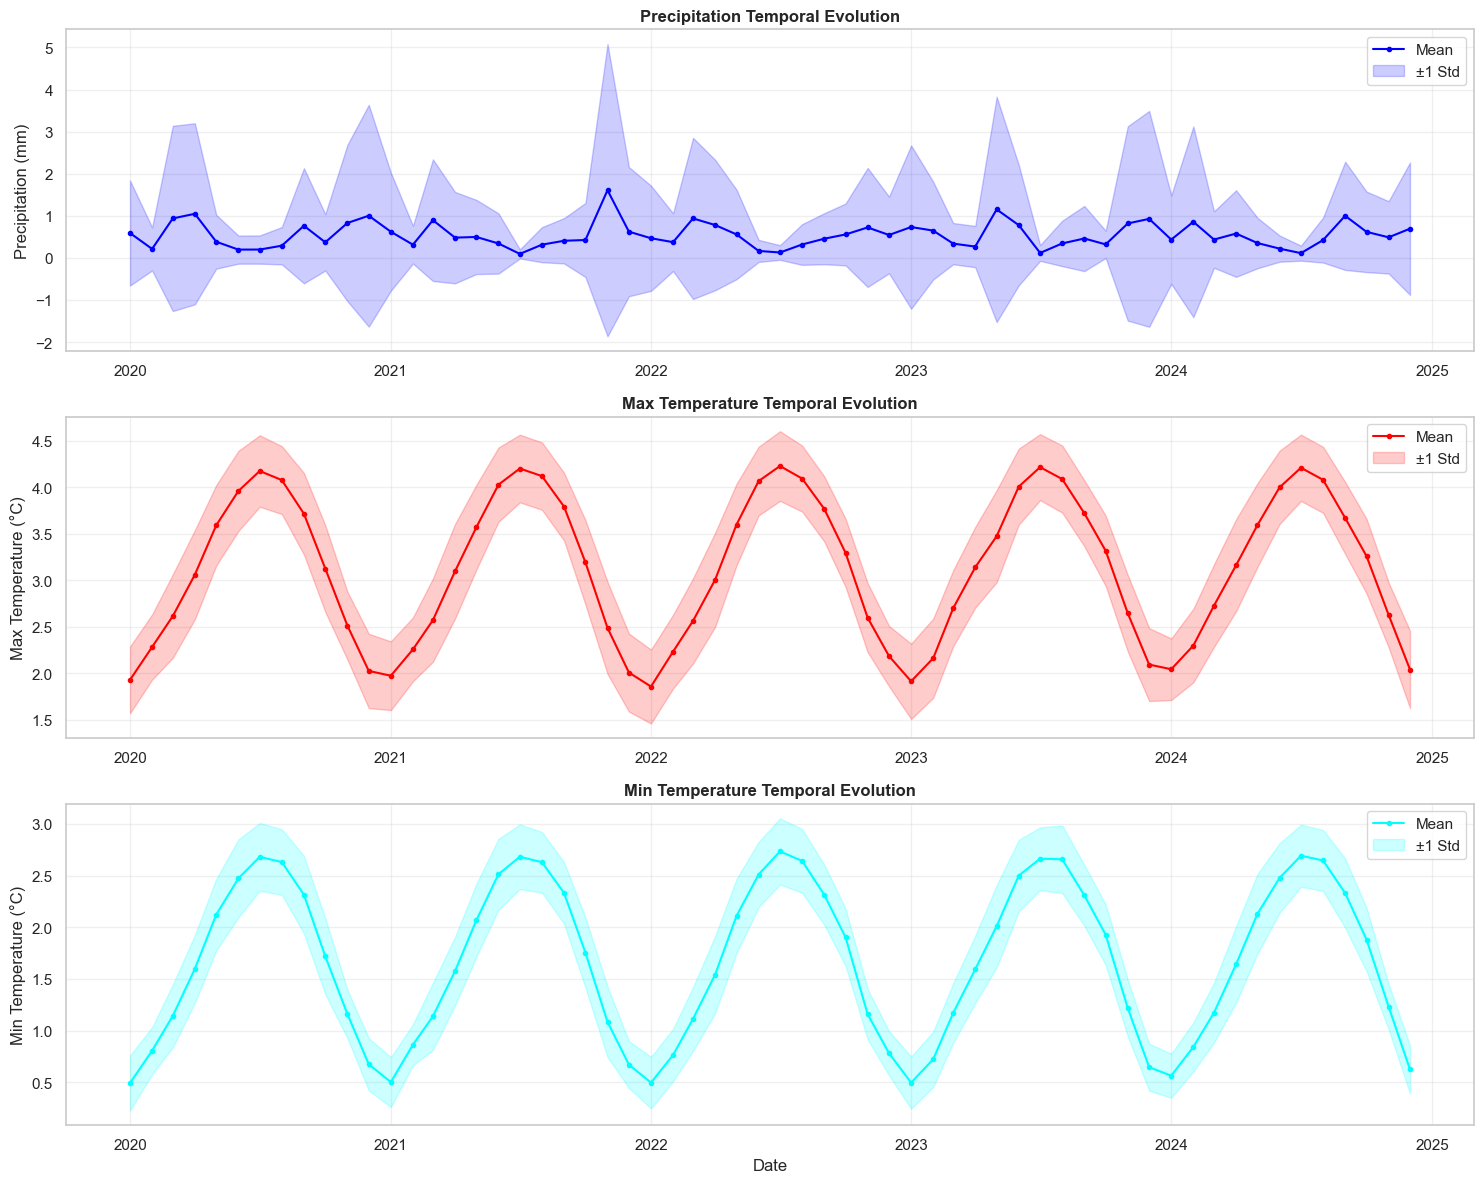

In [16]:
# Temporal analysis - trends and seasonality
print("\n📊 Temporal Analysis - Trends & Seasonality\n")

fig, axes = plt.subplots(3, 1, figsize=(15, 12))

# Precipitation over time
axes[0].plot(prec_stats['date'], prec_stats['mean'], marker='o', markersize=3, color='blue', label='Mean')
axes[0].fill_between(prec_stats['date'], 
                      prec_stats['mean'] - prec_stats['std'], 
                      prec_stats['mean'] + prec_stats['std'], 
                      alpha=0.2, color='blue', label='±1 Std')
axes[0].set_title('Precipitation Temporal Evolution', fontweight='bold')
axes[0].set_ylabel('Precipitation (mm)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Max Temperature over time
axes[1].plot(tmax_stats['date'], tmax_stats['mean'], marker='o', markersize=3, color='red', label='Mean')
axes[1].fill_between(tmax_stats['date'], 
                      tmax_stats['mean'] - tmax_stats['std'], 
                      tmax_stats['mean'] + tmax_stats['std'], 
                      alpha=0.2, color='red', label='±1 Std')
axes[1].set_title('Max Temperature Temporal Evolution', fontweight='bold')
axes[1].set_ylabel('Max Temperature (°C)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Min Temperature over time
axes[2].plot(tmin_stats['date'], tmin_stats['mean'], marker='o', markersize=3, color='cyan', label='Mean')
axes[2].fill_between(tmin_stats['date'], 
                      tmin_stats['mean'] - tmin_stats['std'], 
                      tmin_stats['mean'] + tmin_stats['std'], 
                      alpha=0.2, color='cyan', label='±1 Std')
axes[2].set_title('Min Temperature Temporal Evolution', fontweight='bold')
axes[2].set_ylabel('Min Temperature (°C)')
axes[2].set_xlabel('Date')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 5. Load Fire Points Data

In [17]:
# Load fire points data
print("\n🔥 Loading fire points data...\n")

fires_df = pd.read_csv(FIRES_CSV)

print(f"✅ Loaded fire data: {fires_df.shape}")
print(f"\nColumns: {list(fires_df.columns)}")
print(f"\nFirst few rows:")
display(fires_df.head())

print(f"\nClass distribution:")
print(fires_df['class'].value_counts().sort_index())

# Convert to GeoDataFrame
fires_gdf = gpd.GeoDataFrame(
    fires_df,
    geometry=gpd.points_from_xy(fires_df['longitude'], fires_df['latitude']),
    crs='EPSG:4326'
)

print(f"\n✅ Converted to GeoDataFrame")
print(f"   CRS: {fires_gdf.crs}")
print(f"   Bounds: {fires_gdf.total_bounds}")


🔥 Loading fire points data...

✅ Loaded fire data: (8212, 3)

Columns: ['longitude', 'latitude', 'class']

First few rows:


,longitude,latitude,class
0,9.42603,37.00734,1
1,0.84846,36.48433,0
2,4.13116,36.62614,1
3,7.28408,36.89190,1
4,8.46453,35.31460,0



Class distribution:
class
0    4927
1    3285
Name: count, dtype: int64

✅ Converted to GeoDataFrame
   CRS: EPSG:4326
   Bounds: [-2.18114 33.0164  11.11035 37.32346]



📍 Checking spatial coverage...



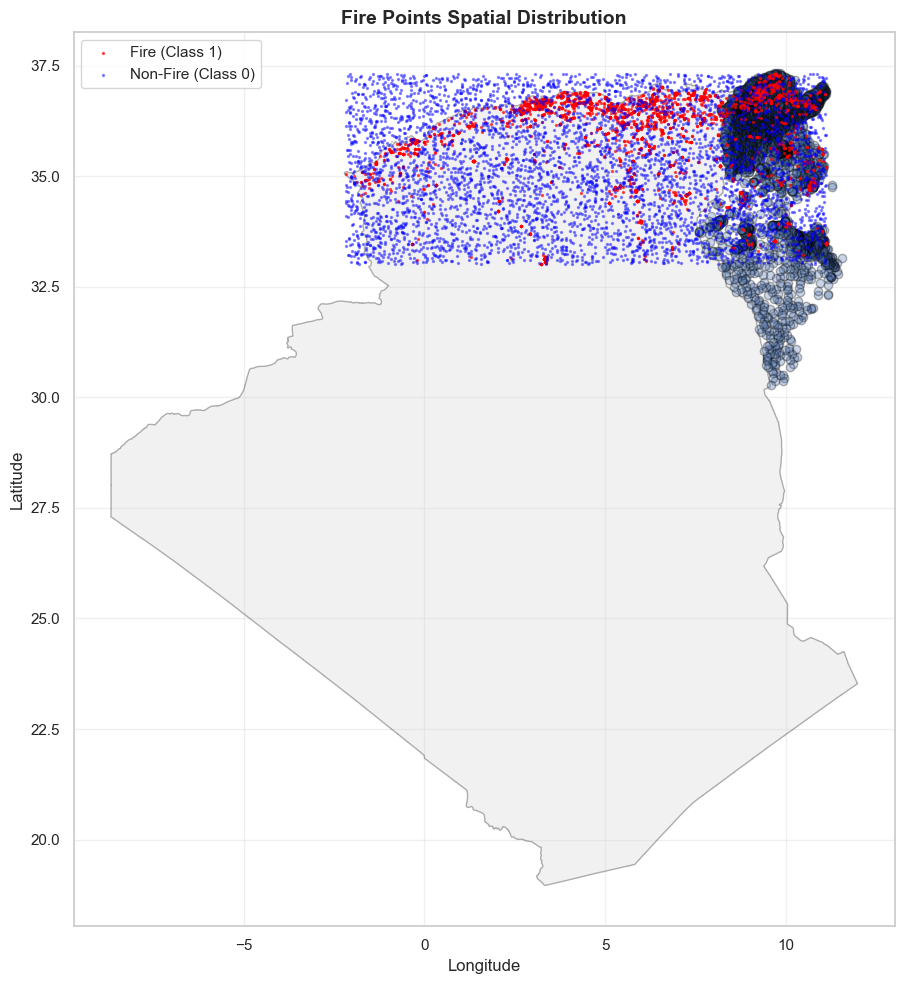

✅ Fire points cover the region:
   Longitude: [-2.18, 11.11]
   Latitude: [33.02, 37.32]


In [18]:
# Check spatial coverage
print("\n📍 Checking spatial coverage...\n")

fig, ax = plt.subplots(figsize=(12, 10))

# Plot boundaries
boundaries.plot(ax=ax, edgecolor='black', facecolor='lightgray', alpha=0.3)

# Plot fire points colored by class
fires_gdf[fires_gdf['class'] == 1].plot(ax=ax, markersize=2, color='red', alpha=0.6, label='Fire (Class 1)')
fires_gdf[fires_gdf['class'] == 0].plot(ax=ax, markersize=2, color='blue', alpha=0.4, label='Non-Fire (Class 0)')

ax.set_title('Fire Points Spatial Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"✅ Fire points cover the region:")
print(f"   Longitude: [{fires_df['longitude'].min():.2f}, {fires_df['longitude'].max():.2f}]")
print(f"   Latitude: [{fires_df['latitude'].min():.2f}, {fires_df['latitude'].max():.2f}]")

# 6. Extract Climate Values at Fire Point Locations

In [19]:
# Define seasons
def get_season(month):
    """Determine season from month number."""
    if month in [12, 1, 2]:
        return 'winter'
    elif month in [3, 4, 5]:
        return 'spring'
    elif month in [6, 7, 8]:
        return 'summer'
    else:  # 9, 10, 11
        return 'autumn'

# Add season column to statistics
prec_stats['season'] = prec_stats['date'].dt.month.apply(get_season)
tmax_stats['season'] = tmax_stats['date'].dt.month.apply(get_season)
tmin_stats['season'] = tmin_stats['date'].dt.month.apply(get_season)

print("\n⚡ Extracting climate values at fire locations...\n")
print(f"Processing {len(fires_df)} fire points...")
print(f"Extracting data for {len(common_dates)} dates across 4 seasons...\n")


⚡ Extracting climate values at fire locations...

Processing 8212 fire points...
Extracting data for 60 dates across 4 seasons...



In [20]:
# Extract climate values at fire points
def extract_climate_at_points(fires_df, clipped_data_dict, multiplier=1.0):
    """
    Extract climate values at fire point locations.
    Returns DataFrame with values for each date.
    """
    results = []
    
    for date, (data, transform, meta) in clipped_data_dict.items():
        # Create coordinate pairs
        coords = [(x, y) for x, y in zip(fires_df['longitude'], fires_df['latitude'])]
        
        # Extract values using rasterio's sample method (need to use original raster file)
        values = []
        for lon, lat in coords:
            # Convert geographic coordinates to pixel coordinates
            from rasterio.transform import rowcol
            row, col = rowcol(transform, lon, lat)
            
            # Check if within bounds
            if 0 <= row < data.shape[0] and 0 <= col < data.shape[1]:
                value = data[row, col]
                # Check for nodata
                if meta['nodata'] is not None and value == meta['nodata']:
                    values.append(np.nan)
                else:
                    values.append(value * multiplier)
            else:
                values.append(np.nan)
        
        results.append({
            'date': date,
            'values': values
        })
    
    return results

print("Extracting precipitation values...")
prec_extractions = extract_climate_at_points(fires_df, clipped_prec, multiplier=0.1)

print("Extracting max temperature values...")
tmax_extractions = extract_climate_at_points(fires_df, clipped_tmax, multiplier=0.1)

print("Extracting min temperature values...")
tmin_extractions = extract_climate_at_points(fires_df, clipped_tmin, multiplier=0.1)

print("\n✅ Climate values extracted for all fire points")

Extracting precipitation values...
Extracting max temperature values...
Extracting max temperature values...
Extracting min temperature values...
Extracting min temperature values...

✅ Climate values extracted for all fire points

✅ Climate values extracted for all fire points


## 🔍 Diagnostic: Check for Missing Climate Data

In [21]:
print("\n" + "="*80)
print("🔍 DIAGNOSTIC: Analyzing Climate Data Extraction")
print("="*80 + "\n")

# Store original fires_df before any seasonal aggregation
fires_df_original = fires_df.copy()
original_count = len(fires_df_original)

print(f"📊 Original fire points: {original_count}")
print(f"   Class 0 (Non-Fire): {len(fires_df_original[fires_df_original['class'] == 0])}")
print(f"   Class 1 (Fire): {len(fires_df_original[fires_df_original['class'] == 1])}")

# Check for NaN values in extracted climate data
print("\n🔍 Checking for missing climate values (NaN)...\n")

# Count NaNs in precipitation extractions
nan_counts_prec = {}
for season in ['winter', 'spring', 'summer', 'autumn']:
    season_extractions = [e for e in prec_extractions if get_season(e['date'].month) == season]
    if season_extractions:
        all_values = np.concatenate([e['values'] for e in season_extractions])
        nan_count = np.isnan(all_values).sum()
        total_count = len(all_values)
        nan_counts_prec[season] = (nan_count, total_count)
        print(f"   Precipitation ({season}): {nan_count:,} NaN values out of {total_count:,} ({nan_count/total_count*100:.2f}%)")

# Count NaNs in temperature extractions
nan_counts_tmax = {}
for season in ['winter', 'spring', 'summer', 'autumn']:
    season_extractions = [e for e in tmax_extractions if get_season(e['date'].month) == season]
    if season_extractions:
        all_values = np.concatenate([e['values'] for e in season_extractions])
        nan_count = np.isnan(all_values).sum()
        total_count = len(all_values)
        nan_counts_tmax[season] = (nan_count, total_count)
        print(f"   Max Temp ({season}): {nan_count:,} NaN values out of {total_count:,} ({nan_count/total_count*100:.2f}%)")

nan_counts_tmin = {}
for season in ['winter', 'spring', 'summer', 'autumn']:
    season_extractions = [e for e in tmin_extractions if get_season(e['date'].month) == season]
    if season_extractions:
        all_values = np.concatenate([e['values'] for e in season_extractions])
        nan_count = np.isnan(all_values).sum()
        total_count = len(all_values)
        nan_counts_tmin[season] = (nan_count, total_count)
        print(f"   Min Temp ({season}): {nan_count:,} NaN values out of {total_count:,} ({nan_count/total_count*100:.2f}%)")

# Identify which fire points have missing climate data
print("\n🔍 Identifying fire points with missing climate data...\n")

# Check which points have NaN in any extraction
points_with_nan = set()
for extraction in prec_extractions + tmax_extractions + tmin_extractions:
    values = extraction['values']
    nan_indices = [i for i, v in enumerate(values) if np.isnan(v)]
    points_with_nan.update(nan_indices)

print(f"   Total fire points with at least one NaN value: {len(points_with_nan)}")
print(f"   Percentage of affected points: {len(points_with_nan)/original_count*100:.2f}%")

if len(points_with_nan) > 0:
    # Analyze affected points by class
    affected_points_df = fires_df_original.iloc[list(points_with_nan)]
    print("\n   Distribution of affected points by class:")
    print(f"      Class 0 (Non-Fire): {len(affected_points_df[affected_points_df['class'] == 0])}")
    print(f"      Class 1 (Fire): {len(affected_points_df[affected_points_df['class'] == 1])}")
    
    # Show geographic distribution of affected points
    print("\n   Geographic range of affected points:")
    print(f"      Longitude: [{affected_points_df['longitude'].min():.4f}, {affected_points_df['longitude'].max():.4f}]")
    print(f"      Latitude: [{affected_points_df['latitude'].min():.4f}, {affected_points_df['latitude'].max():.4f}]")
    
    # Show sample of affected points
    print("\n   Sample of affected fire points:")
    display(affected_points_df[['longitude', 'latitude', 'class']].head(10))

print("\n" + "="*80)
print("✅ Diagnostic Complete")
print("="*80)


🔍 DIAGNOSTIC: Analyzing Climate Data Extraction

📊 Original fire points: 8212
   Class 0 (Non-Fire): 4927
   Class 1 (Fire): 3285

🔍 Checking for missing climate values (NaN)...

   Precipitation (winter): 24,555 NaN values out of 123,180 (19.93%)
   Precipitation (spring): 24,555 NaN values out of 123,180 (19.93%)
   Precipitation (summer): 24,555 NaN values out of 123,180 (19.93%)
   Precipitation (autumn): 24,555 NaN values out of 123,180 (19.93%)
   Max Temp (winter): 24,555 NaN values out of 123,180 (19.93%)
   Max Temp (spring): 24,555 NaN values out of 123,180 (19.93%)
   Max Temp (summer): 24,555 NaN values out of 123,180 (19.93%)
   Max Temp (autumn): 24,555 NaN values out of 123,180 (19.93%)
   Min Temp (winter): 24,555 NaN values out of 123,180 (19.93%)
   Min Temp (spring): 24,555 NaN values out of 123,180 (19.93%)
   Min Temp (summer): 24,555 NaN values out of 123,180 (19.93%)
   Min Temp (autumn): 24,555 NaN values out of 123,180 (19.93%)

🔍 Identifying fire points with 

,longitude,latitude,class
1,0.84846,36.48433,0
8193,-1.76340,33.24393,0
8196,6.01683,37.10231,0
6,5.36770,37.17534,0
9,0.87602,36.50915,0
8203,4.68488,37.09120,0
8208,10.55308,36.97253,0
20,7.62144,37.15783,0
23,-1.09689,37.12808,0
29,9.59772,33.38426,0



✅ Diagnostic Complete


In [22]:
# Aggregate by season
print("\n📊 Aggregating climate data by season...\n")

# Initialize seasonal columns in fires_df
for season in ['winter', 'spring', 'summer', 'autumn']:
    fires_df[f'prec_{season}'] = 0.0
    fires_df[f'tmax_{season}'] = 0.0
    fires_df[f'tmin_{season}'] = 0.0

# Aggregate precipitation by season
for extraction in prec_extractions:
    date = extraction['date']
    season = get_season(date.month)
    values = np.array(extraction['values'])
    
    # Add to seasonal accumulation (will average later)
    fires_df[f'prec_{season}'] += np.nan_to_num(values, nan=0.0)

# Aggregate max temperature by season
for extraction in tmax_extractions:
    date = extraction['date']
    season = get_season(date.month)
    values = np.array(extraction['values'])
    fires_df[f'tmax_{season}'] += np.nan_to_num(values, nan=0.0)

# Aggregate min temperature by season
for extraction in tmin_extractions:
    date = extraction['date']
    season = get_season(date.month)
    values = np.array(extraction['values'])
    fires_df[f'tmin_{season}'] += np.nan_to_num(values, nan=0.0)

# Calculate averages (divide by number of months per season)
season_months = {'winter': 3, 'spring': 3, 'summer': 3, 'autumn': 3}

# Count how many dates per season we have
season_counts = {season: len([d for d in common_dates if get_season(d.month) == season]) 
                 for season in ['winter', 'spring', 'summer', 'autumn']}

print("Dates per season:")
for season, count in season_counts.items():
    print(f"  {season.capitalize()}: {count} months")

# Divide by actual counts to get averages
for season in ['winter', 'spring', 'summer', 'autumn']:
    if season_counts[season] > 0:
        fires_df[f'prec_{season}'] /= season_counts[season]
        fires_df[f'tmax_{season}'] /= season_counts[season]
        fires_df[f'tmin_{season}'] /= season_counts[season]

print("\n✅ Seasonal aggregation complete")
print(f"\nMerged dataset shape: {fires_df.shape}")
print(f"New columns: {[col for col in fires_df.columns if '_' in col]}")

print("\nSample of merged data:")
display(fires_df.head())


📊 Aggregating climate data by season...

Dates per season:
  Winter: 15 months
  Spring: 15 months
  Summer: 15 months
  Autumn: 15 months

✅ Seasonal aggregation complete

Merged dataset shape: (8212, 15)
New columns: ['prec_winter', 'tmax_winter', 'tmin_winter', 'prec_spring', 'tmax_spring', 'tmin_spring', 'prec_summer', 'tmax_summer', 'tmin_summer', 'prec_autumn', 'tmax_autumn', 'tmin_autumn']

Sample of merged data:


,longitude,latitude,class,prec_winter,tmax_winter,tmin_winter,prec_spring,tmax_spring,tmin_spring,prec_summer,tmax_summer,tmin_summer,prec_autumn,tmax_autumn,tmin_autumn
0,9.42603,37.00734,1,7.271833,1.578333,0.676667,4.828333,2.130000,1.070000,0.762667,3.321667,2.016667,4.860667,2.568333,1.516667
1,0.84846,36.48433,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,4.13116,36.62614,1,8.378667,1.468333,0.636667,6.137000,2.106667,1.151667,0.805667,3.253333,2.153333,7.044167,2.495000,1.543333
3,7.28408,36.89190,1,8.221000,1.731667,0.863333,4.380167,2.191667,1.166667,0.653500,3.185000,2.028333,5.255833,2.625000,1.630000
4,8.46453,35.31460,0,1.872667,1.245000,0.356667,3.220500,2.118333,0.906667,1.483500,3.385000,1.955000,2.466500,2.291667,1.265000


## 🔍 Diagnostic: Check Row Count After Aggregation

In [23]:
print("\n" + "="*80)
print("🔍 DIAGNOSTIC: Comparing Row Counts Before vs After")
print("="*80 + "\n")

current_count = len(fires_df)
lost_rows = original_count - current_count

print(f"📊 Row Count Comparison:")
print(f"   Original fire points: {original_count}")
print(f"   Current fire points: {current_count}")
print(f"   Lost rows: {lost_rows} ({lost_rows/original_count*100:.2f}%)")

if lost_rows > 0:
    print(f"\n⚠️  WARNING: {lost_rows} rows were lost during aggregation!")
    print(f"   This likely happened due to NaN values being dropped somewhere.")
    
    # Check class distribution of remaining points
    print("\n📊 Class distribution of remaining points:")
    print(f"   Class 0 (Non-Fire): {len(fires_df[fires_df['class'] == 0])}")
    print(f"   Class 1 (Fire): {len(fires_df[fires_df['class'] == 1])}")
    
    # Compare with original
    print("\n📊 Class distribution of original points:")
    print(f"   Class 0 (Non-Fire): {len(fires_df_original[fires_df_original['class'] == 0])}")
    print(f"   Class 1 (Fire): {len(fires_df_original[fires_df_original['class'] == 1])}")
    
    # Calculate losses by class
    lost_class0 = len(fires_df_original[fires_df_original['class'] == 0]) - len(fires_df[fires_df['class'] == 0])
    lost_class1 = len(fires_df_original[fires_df_original['class'] == 1]) - len(fires_df[fires_df['class'] == 1])
    
    print(f"\n📊 Rows lost by class:")
    print(f"   Class 0 (Non-Fire): {lost_class0} rows lost")
    print(f"   Class 1 (Fire): {lost_class1} rows lost")
else:
    print("\n✅ No rows lost - all fire points retained!")

print("\n" + "="*80)


🔍 DIAGNOSTIC: Comparing Row Counts Before vs After

📊 Row Count Comparison:
   Original fire points: 8212
   Current fire points: 8212
   Lost rows: 0 (0.00%)

✅ No rows lost - all fire points retained!



---
# 7. Data Preprocessing

In [24]:
# Drop duplicates
print("\n🔧 Data Preprocessing...\n")

print("Step 1: Dropping duplicates...")
before_dup = len(fires_df)
fires_df = fires_df.drop_duplicates()
after_dup = len(fires_df)
print(f"  Removed {before_dup - after_dup} duplicate rows")
print(f"  Remaining rows: {after_dup}")


🔧 Data Preprocessing...

Step 1: Dropping duplicates...
  Removed 0 duplicate rows
  Remaining rows: 8212


In [25]:
# Handle missing values
print("\nStep 2: Handling missing values...\n")

# Check for missing values
missing_before = fires_df.isnull().sum()
print("Missing values before:")
print(missing_before[missing_before > 0])

# Identify column types
numeric_cols = fires_df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = fires_df.select_dtypes(include=['object']).columns.tolist()

print(f"\nNumeric columns: {numeric_cols}")
print(f"Categorical columns: {categorical_cols}")

# Fill missing values in numeric columns with median
for col in numeric_cols:
    if fires_df[col].isnull().sum() > 0:
        median_val = fires_df[col].median()
        fires_df[col].fillna(median_val, inplace=True)
        print(f"  {col}: filled {fires_df[col].isnull().sum()} missing values with median {median_val:.2f}")

# Fill missing values in categorical columns with mode
for col in categorical_cols:
    if fires_df[col].isnull().sum() > 0:
        mode_val = fires_df[col].mode()[0]
        fires_df[col].fillna(mode_val, inplace=True)
        print(f"  {col}: filled with mode '{mode_val}'")

# Check after
missing_after = fires_df.isnull().sum().sum()
print(f"\n✅ Missing values after: {missing_after}")


Step 2: Handling missing values...

Missing values before:
Series([], dtype: int64)

Numeric columns: ['longitude', 'latitude', 'class', 'prec_winter', 'tmax_winter', 'tmin_winter', 'prec_spring', 'tmax_spring', 'tmin_spring', 'prec_summer', 'tmax_summer', 'tmin_summer', 'prec_autumn', 'tmax_autumn', 'tmin_autumn']
Categorical columns: []

✅ Missing values after: 0


In [26]:
# Detect and replace outliers using IQR method
print("\nStep 3: Detecting and replacing outliers...\n")

# Exclude coordinates and class from outlier detection
outlier_cols = [col for col in numeric_cols if col not in ['longitude', 'latitude', 'class']]

print(f"Checking outliers in: {outlier_cols}\n")

for col in outlier_cols:
    Q1 = fires_df[col].quantile(0.25)
    Q3 = fires_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers_mask = (fires_df[col] < lower_bound) | (fires_df[col] > upper_bound)
    outliers_count = outliers_mask.sum()
    
    if outliers_count > 0:
        median_val = fires_df[col].median()
        fires_df.loc[outliers_mask, col] = median_val
        print(f"  {col}: Replaced {outliers_count} outliers ({100*outliers_count/len(fires_df):.2f}%) with median {median_val:.2f}")
        print(f"    Valid range was: [{lower_bound:.2f}, {upper_bound:.2f}]")

print("\n✅ Outlier handling complete")


Step 3: Detecting and replacing outliers...

Checking outliers in: ['prec_winter', 'tmax_winter', 'tmin_winter', 'prec_spring', 'tmax_spring', 'tmin_spring', 'prec_summer', 'tmax_summer', 'tmin_summer', 'prec_autumn', 'tmax_autumn', 'tmin_autumn']

  prec_winter: Replaced 125 outliers (1.52%) with median 1.78
    Valid range was: [-5.94, 11.02]
  tmax_winter: Replaced 1637 outliers (19.93%) with median 1.40
    Valid range was: [0.29, 2.53]
  tmax_spring: Replaced 1661 outliers (20.23%) with median 2.14
    Valid range was: [1.21, 3.00]
  tmin_spring: Replaced 1637 outliers (19.93%) with median 0.99
    Valid range was: [0.14, 1.78]
  tmax_summer: Replaced 1637 outliers (19.93%) with median 3.33
    Valid range was: [2.30, 4.31]
  tmin_summer: Replaced 1761 outliers (21.44%) with median 2.00
    Valid range was: [1.17, 2.75]
  prec_autumn: Replaced 51 outliers (0.62%) with median 1.94
    Valid range was: [-3.59, 8.15]
  tmax_autumn: Replaced 1637 outliers (19.93%) with median 2.44
  

In [27]:
# Normalize/standardize features
print("\nStep 4: Normalizing features...\n")

from sklearn.preprocessing import StandardScaler

# Columns to normalize (exclude coordinates and class)
cols_to_normalize = [col for col in numeric_cols if col not in ['longitude', 'latitude', 'class']]

print(f"Normalizing columns: {cols_to_normalize}\n")

scaler = StandardScaler()
fires_df[cols_to_normalize] = scaler.fit_transform(fires_df[cols_to_normalize])

print("✅ Feature normalization complete")
print("\nSample of normalized data:")
display(fires_df[cols_to_normalize].describe())


Step 4: Normalizing features...

Normalizing columns: ['prec_winter', 'tmax_winter', 'tmin_winter', 'prec_spring', 'tmax_spring', 'tmin_spring', 'prec_summer', 'tmax_summer', 'tmin_summer', 'prec_autumn', 'tmax_autumn', 'tmin_autumn']

Normalizing columns: ['prec_winter', 'tmax_winter', 'tmin_winter', 'prec_spring', 'tmax_spring', 'tmin_spring', 'prec_summer', 'tmax_summer', 'tmin_summer', 'prec_autumn', 'tmax_autumn', 'tmin_autumn']

✅ Feature normalization complete

Sample of normalized data:
✅ Feature normalization complete

Sample of normalized data:


,prec_winter,tmax_winter,tmin_winter,prec_spring,tmax_spring,tmin_spring,prec_summer,tmax_summer,tmin_summer,prec_autumn,tmax_autumn,tmin_autumn
count,8.212000e+03,8.212000e+03,8.212000e+03,8.212000e+03,8.212000e+03,8.212000e+03,8.212000e+03,8.212000e+03,8.212000e+03,8.212000e+03,8.212000e+03,8.212000e+03
mean,1.577187e-16,9.442033e-17,-1.134558e-16,1.545957e-17,-2.050803e-15,-3.790874e-16,2.432432e-16,-2.547078e-17,-7.532671e-16,-1.423470e-16,-2.121510e-15,1.272782e-15
std,1.000061e+00,1.000061e+00,1.000061e+00,1.000061e+00,1.000061e+00,1.000061e+00,1.000061e+00,1.000061e+00,1.000061e+00,1.000061e+00,1.000061e+00,1.000061e+00
min,-9.767219e-01,-3.728066e+00,-1.966051e+00,-1.239154e+00,-2.926579e+00,-3.287031e+00,-1.385891e+00,-2.445773e+00,-3.289873e+00,-1.160744e+00,-3.503980e+00,-3.116801e+00
25%,-8.282517e-01,-6.101247e-01,-8.213882e-01,-8.755480e-01,-4.850288e-01,-5.542117e-01,-1.009463e+00,-5.409767e-01,-4.753559e-01,-7.706136e-01,-5.461166e-01,-6.174850e-01
50%,-3.487148e-01,-3.938916e-01,1.687475e-02,-1.089767e-01,-3.696800e-01,-3.573882e-01,1.591809e-01,-3.884187e-01,-3.346300e-01,-2.303157e-01,-3.562291e-01,-3.729036e-01
75%,5.706334e-01,8.267791e-01,9.187301e-01,7.170383e-01,3.544542e-01,4.450464e-01,8.006579e-01,3.845419e-01,2.986363e-01,5.914302e-01,6.224219e-01,6.283516e-01
max,2.904486e+00,2.556644e+00,2.358230e+00,2.958096e+00,2.943394e+00,3.064314e+00,2.743094e+00,2.808035e+00,2.852811e+00,2.690373e+00,3.142083e+00,2.730223e+00


# 8. Merge and Save Final Preprocessed Dataset

In [28]:
# Save final merged dataset (fires + climate features)
print("\n💾 Saving final merged dataset...\n")

# Save the preprocessed and merged dataset
output_file = OUTPUT_DIR / 'fires_with_climate.csv'
fires_df.to_csv(output_file, index=False)

print(f"✅ Dataset saved to: {output_file}")
print("\n" + "="*80)
print("Final dataset preview (first 10 rows):")
print("="*80)
display(fires_df.head(10))


💾 Saving final merged dataset...

✅ Dataset saved to: c:\Users\Azur\Downloads\TP\DM\results\fires_with_climate.csv

Final dataset preview (first 10 rows):


,longitude,latitude,class,prec_winter,tmax_winter,tmin_winter,prec_spring,tmax_spring,tmin_spring,prec_summer,tmax_summer,tmin_summer,prec_autumn,tmax_autumn,tmin_autumn
0,9.42603,37.00734,1,1.594895,0.359437,0.912949,1.040241,-0.395313,0.005978,0.530166,-0.429101,-0.243158,1.165994,0.206130,0.528990
1,0.84846,36.48433,0,-0.976722,-0.393892,-1.434187,-1.239154,-0.369680,-0.357388,-1.385891,-0.388419,-0.334630,-1.160744,-0.356229,-0.372904
2,4.13116,36.62614,1,1.986316,-0.100931,0.774202,1.658046,-0.485029,0.376915,0.638195,-0.667382,0.333818,2.211207,-0.115218,0.651281
3,7.28408,36.89190,1,1.930559,1.001161,1.560435,0.828667,-0.158207,0.445046,0.255905,-0.905663,-0.193904,1.355155,0.454444,1.048726
4,8.46453,35.31460,0,-0.314471,-1.035616,-0.197027,0.281203,-0.440171,-0.735895,2.341124,-0.208255,-0.503501,0.019938,-1.006229,-0.625128
5,4.65055,36.84538,0,1.725388,0.652398,1.340752,1.116011,-0.568336,0.588879,0.393663,-1.603071,0.010148,2.329523,-0.180948,0.949365
6,5.36770,37.17534,0,-0.976722,-0.393892,-1.434187,-1.239154,-0.369680,-0.357388,-1.385891,-0.388419,-0.334630,-1.160744,-0.356229,-0.372904
7,1.42549,36.16594,0,0.207091,0.673323,0.704828,0.334864,0.405720,0.164951,-0.495276,0.878539,0.354927,0.281700,0.878040,0.314982
8,4.11798,33.48140,0,-0.824421,0.464066,-0.064061,-0.839689,1.392593,0.876544,-0.657739,1.680559,1.501842,-0.704316,0.907253,0.253836
9,0.87602,36.50915,0,-0.976722,-0.393892,-1.434187,-1.239154,-0.369680,-0.357388,-1.385891,-0.388419,-0.334630,-1.160744,-0.356229,-0.372904
